# HR analytics: удовлетворённость и вероятность увольнения на основе ML

**ЦЕЛЬ РАБОТЫ:** Разработка прогностических моделей для оценки уровня удовлетворённости сотрудников работой в компании и предсказания вероятности их увольнения с целью оптимизации HR-процессов и минимизации финансовых потерь компании.

**Задачи:**
1. Предсказание уровня удовлетворённости сотрудника
2. Предсказание увольнения сотрудника из компании 

Решение этих задач поможет компании:

* Оперативно реагировать на проблемы;
* Оптимизировать HR-процессы;
* Снизить риски потери важных сотрудников;
* Улучшить общую эффективность управления персоналом.

**ПЛАН РАБОТЫ:**

**Задача 1: предсказание уровня удовлетворённости сотрудника**
 - Загрузка данных
 - Предобработка данных
 - Исследовательский анализ данных
 - Корреляционный анализ данных
 -  Подготовка данных
 - Обучение моделей
 - Выводы по первой задаче
    
**Задача 2: предсказание увольнения сотрудника из компании**
 - Загрузка данных
 - Предобработка данных
 - Исследовательский анализ данных
 - Корреляционный анализ данных
 - Добавление нового входного признака
 - Подготовка данных
 - Обучение модели
 - Выводы по второй задаче

**Общий вывод**

In [1]:
# установим и импортируем необходимые библиотеки
!pip install phik -q
!pip install -U scikit-learn -q
!pip install shap -q

import os
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from phik import phik_matrix
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.tree import DecisionTreeClassifier,  DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier, DummyRegressor
import shap
from scipy import stats as st

## Задача 1: предсказание уровня удовлетворённости сотрудника

### Загрузка данных

In [2]:
path = 'datasets'

if os.path.exists(path):
    df_train = pd.read_csv(os.path.join(path, 'train_job_satisfaction_rate.csv'))
    df_test_features = pd.read_csv(os.path.join(path, 'test_features.csv'))
    df_test_target =  pd.read_csv(os.path.join(path, 'test_target_job_satisfaction_rate.csv'))
else:
    print('Something is wrong')

In [3]:
# выводим общую информацию и первые строки первого датафрейма
print(df_train.info())
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB
None


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


В первом датафрейме представлена тренировочная выборка, содержащая характеристики сотрудников компании: `id` сотрудника, отдел, уровень занимаемой должности, уровень загруженности работой, длительность работы в компании, наличие повышения или нарушений трудового договора за последний год, оценка качества работы руководителем, зарплата и уровень удовлетворенности работой в компании. Всего 4000 строк и 10 столбцов. Названия колонок корректные, типы данных в столбцах соотвествуют требованиям, но есть пропуски.  

In [4]:
# выводим общую информацию и первые строки второго датафрейма
print(df_test_features.info())
df_test_features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB
None


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Во втором датафрейме представлена уже тестовая выборка, содержащая характеристики сотрудников компании. Всего 2000 строк и 9 столбцов со входными признаками. Названия столбцов и типы данных такие же как и в первом датафрейме. Также есть пропущенные значения. 

In [5]:
# выводим общую информацию и первые строки третьего датафрейма
print(df_test_target.info())
df_test_target.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
None


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Во третьем датафрейме содержится тестовая выборка с целевым признаком. Размер - 2000 строк и 2 столбца: id сотрудника и его уровень удовлетворенности работой в компании. Названия столбцов и типы данных подходящие, пропущенных значений нет. 

**Выводы:** Было загружены тренировочная и тестовая выборки данных, содержащие характеристики сотрудников компании. Были проверены корректность типов данных и соответствие данных описанию. В результате в двух таблицах были обнаружены пропущенных значения. 
Таким образом, необходимо провести предобработку данных. 

### Предобработка данных

#### Обработка пропусков

Выведем количество пропусков для каждого столбца первого датафрейма и все строки с пропущенными значениями

In [6]:
print(df_train.isna().sum())
df_train[df_train.isna().any(axis=1)]

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


Оказалось, что у 6 сотрудников не указан отдел компании и у 4 не указан уровень занимаемой должности. Пропусков немного, их мы обработаем позже с помощью пайплайна.

Аналогично рассмотрим второй датафрейм.

In [7]:
print(df_test_features.isna().sum())
df_test_features[df_test_features.isna().any(axis=1)]

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
191,609865,NaN,junior,medium,1,no,no,1,20400
312,471990,sales,NaN,low,1,no,no,3,12000
1196,832342,NaN,junior,medium,1,no,no,4,28800


Здесь у нас только два сотрудника их неизвестных отделов и один с неизвестным уровнем занимаемой должности.

In [8]:
print(f'В третьем датафрейме {df_test_target.isna().sum().sum()} пропусков')

В третьем датафрейме 0 пропусков


#### Обработка явных дубликатов

In [9]:
# выведем суммарное количество явных дубликатов 
print(f'В первом датафрейме {df_train.duplicated().sum()} дубликатов') 
print(f'Во втором датафрейме {df_test_features.duplicated().sum()} дубликатов')
print(f'В третьем датафрейме {df_test_target.duplicated().sum()} дубликатов')

В первом датафрейме 0 дубликатов
Во втором датафрейме 0 дубликатов
В третьем датафрейме 0 дубликатов


In [10]:
# выведем суммарное количество дубликатов в столбце id 
print(f'В столбце "id" первого датафрейма {df_train.duplicated(subset="id").sum()} дубликатов') 
print(f'В столбце "id" второго датафрейма {df_test_features.duplicated(subset="id").sum()} дубликатов')
print(f'В столюце "id" третьего датафрейма {df_test_target.duplicated(subset="id").sum()} дубликатов')

В столбце "id" первого датафрейма 0 дубликатов
В столбце "id" второго датафрейма 0 дубликатов
В столюце "id" третьего датафрейма 0 дубликатов


Явных дубликов нет, дополнительно мы убедились, что нет сотрудников с одинаковым `id`.

#### Обработка неявных дубликатов

Выведем уникальные значения для категориальных столбцов первой таблицы

In [11]:
cat_cols = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_train[col].unique()}')

В столбце "dept" следующие уникальные значения: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'sinior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'high' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Неявных дубликатов нет, но есть опечатки. Исправим их.

In [12]:
df_train['level'] = df_train['level'].str.replace('sinior', 'senior')

In [13]:
print('После преобразований в датафрейме df_train:')
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_train[col].unique()}')

После преобразований в датафрейме df_train:
В столбце "dept" следующие уникальные значения: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'senior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'high' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Аналогично, выведем уникальные значения для категориальных столбцов второй таблицы

In [14]:
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_test_features[col].unique()}')

В столбце "dept" следующие уникальные значения: ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'sinior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'low' 'high' ' ']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Здесь, кроме опечатки все в том же столбце "level", есть еще пустые значения (пробелы) в "dept" и "workload". Выведем строки с ними. 

In [15]:
df_test_features.query("(dept == ' ') | (workload == ' ')")

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,,4,no,no,4,28800
1699,822186,,middle,medium,3,no,no,4,38400


Понятно, что это просто пропущенные значения. Изменим значение на NaN и исправим опечатку

In [16]:
df_test_features['dept'] = df_test_features['dept'].replace(r'^\s*$', np.nan, regex=True)
df_test_features['workload'] = df_test_features['workload'].replace(r'^\s*$', np.nan, regex=True)
df_test_features['level'] = df_test_features['level'].str.replace('sinior', 'senior')

In [17]:
print('После преобразований в датафрейме df_test_features:')
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_test_features[col].unique()}')

После преобразований в датафрейме df_test_features:
В столбце "dept" следующие уникальные значения: ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'senior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'low' 'high' nan]
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


**Выводы:** В результате предобработки данных

* Обнаружили пропущенные значения, их обработаем позже
* Убедились в отсутствии явных и неявных дубликатов
* Исправили обнаруженные опечатки 

Данные подготовлены к дальнейшему исследовательскому анализу

### Исследовательский анализ данных

Выведем статистическое описание числовых данных каждого датафрейма. 

In [18]:
df_train.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


In [19]:
df_test_features.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [20]:
df_test_target.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


Глядя на таблицы можно сказать, что аномальных значений нет, среднее значение и медиана примерно одинаковы для каждого столбца. Также видно, что значения в тестовой выборке мало отличаются от аналогичных значений в тренировочной выборке. 

Также построим графики. Для исследовательского анализа данных будем использовать разные графики для категориальных и количественных признаков. 

In [21]:
# круговая диаграмма для категориальных признаков из тренировочной и тестовой выборки
def pie_chart(x):
    colors = plt.cm.Set3(range(len(df_train[x].unique()))) # используем палитру Set3
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    df_train.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('training sample')
    plt.ylabel('')  
    plt.subplot(1, 2, 2) 
    df_test_features.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('test sample')
    plt.ylabel('')  
    plt.suptitle(x, fontsize=15)
    plt.show()

In [22]:
# график для дискретных количественных признаков из тренировочной и тестовой выборки
def countplot(x):
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    sns.countplot(x=x, hue=x, data=df_train, palette='Blues', edgecolor='black', legend=False)
    plt.title('training sample')
    plt.subplot(1, 2, 2) 
    sns.countplot(x=x, hue=x, data=df_test_features, palette='Blues', edgecolor='black', legend=False)
    plt.title('test sample')
    plt.suptitle(x, fontsize=15)
    plt.show()

In [23]:
# Гистограмма и диаграмма размаха для непрерывных количественных признаков  
def hist_and_boxplot(x, df):
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=x, bins=20, kde=True)
    plt.title('Гистограмма')
    plt.subplot(1, 2, 2) 
    sns.boxplot(data=df, y=x, color='#4a90e2', saturation=0.7, width=0.5)
    plt.title('Диаграмма размаха')
    plt.suptitle(x, fontsize=15)
    plt.show()

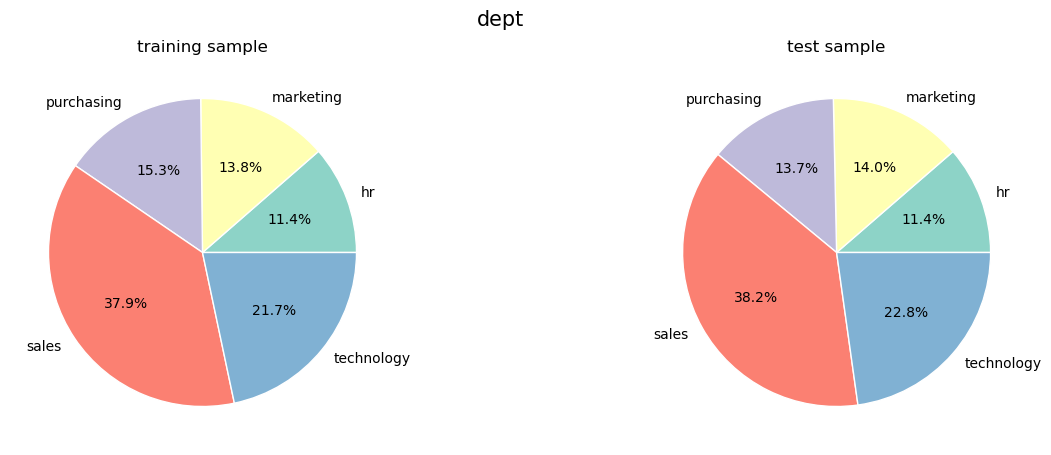

In [24]:
pie_chart('dept')

Сотрудники компании работают в 5 отделах: наибольшее количество (чуть в менее 40 процентов) в отделе продаж, чуть более 20 процентов в техническом отделе, примерно одинаковое количество сотрудников работают в отделе закупок и маркетинговом отделе, на последнем месте по количеству сотрудников  - HR отдел (11.4 процента). Распределения в тренировочной и тестовой выборках почти не отличаются.  

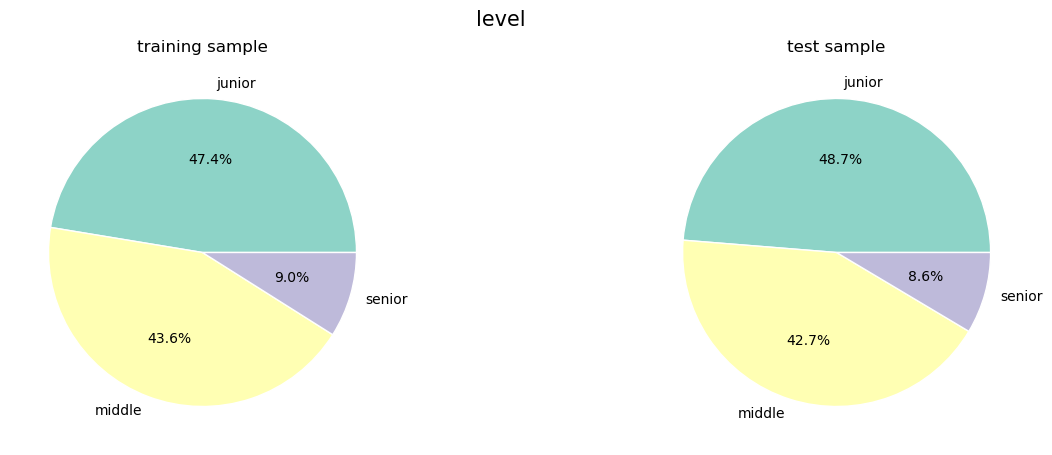

In [25]:
pie_chart('level')

Распределения в тренировочной и тестовой выборках также почти не отличаются. Распределение сотрудников по уровню занимаемой должности демонстрирует преобладание младших специалистов: примерно половина команды имеют уровень `junior`, чуть больше 40 процентов работают на позиции `middle`, а доля `senior-специалистов` меньше 10 процентов.

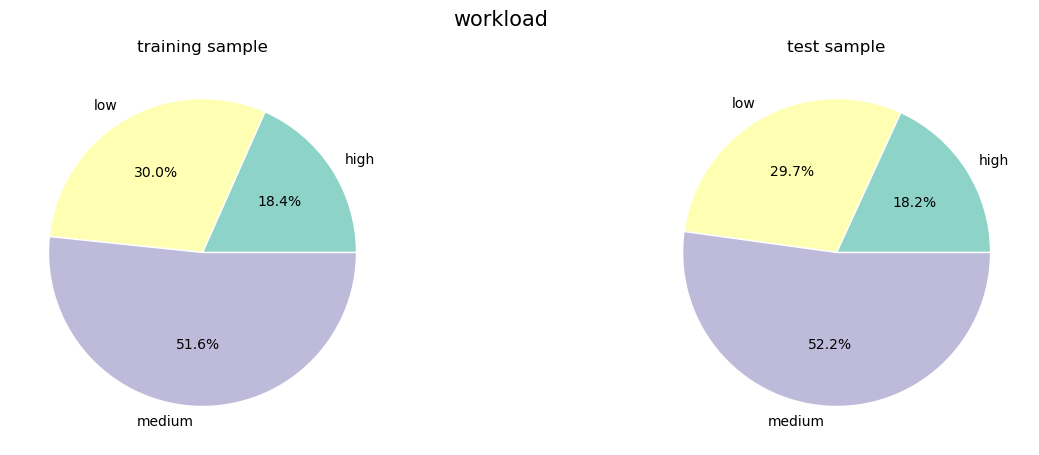

In [26]:
pie_chart('workload')

Распределение рабочей нагрузки следущее: около 50 процентов специалистов имеют среднюю занятость, 30 процентов - низкую и примерно 20 процентов - высокую занятость.

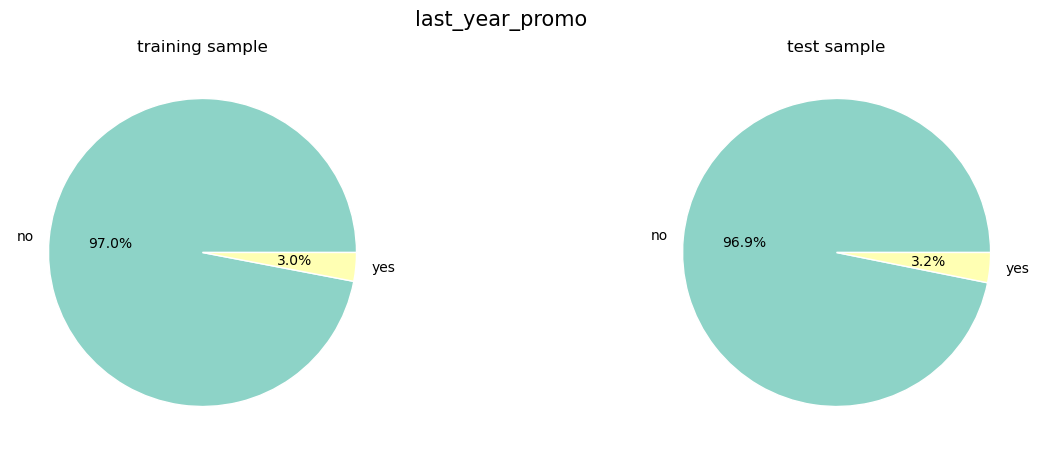

In [27]:
pie_chart('last_year_promo')

Только 3 процента сотрудников получили повышения за последний год.

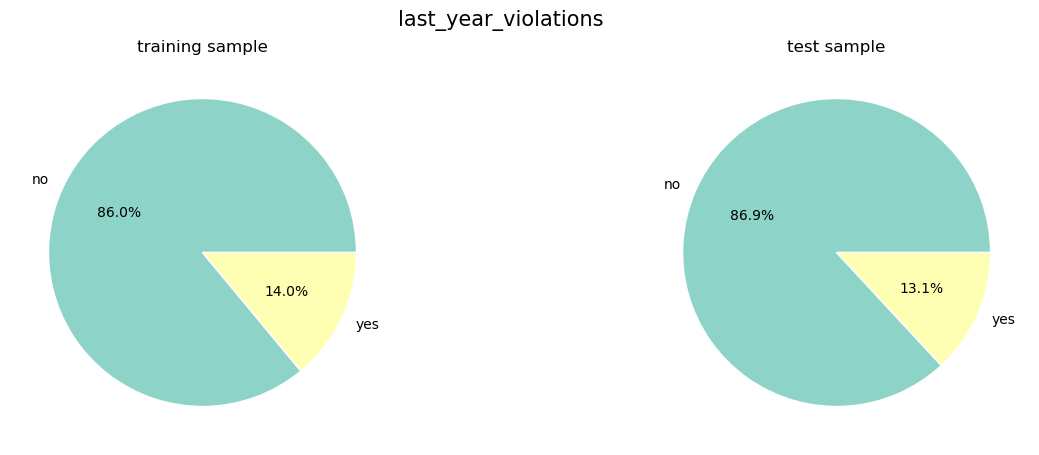

In [28]:
pie_chart('last_year_violations')

Около 14 процентов сотрудников нарушали трудовой договор за последний год. 

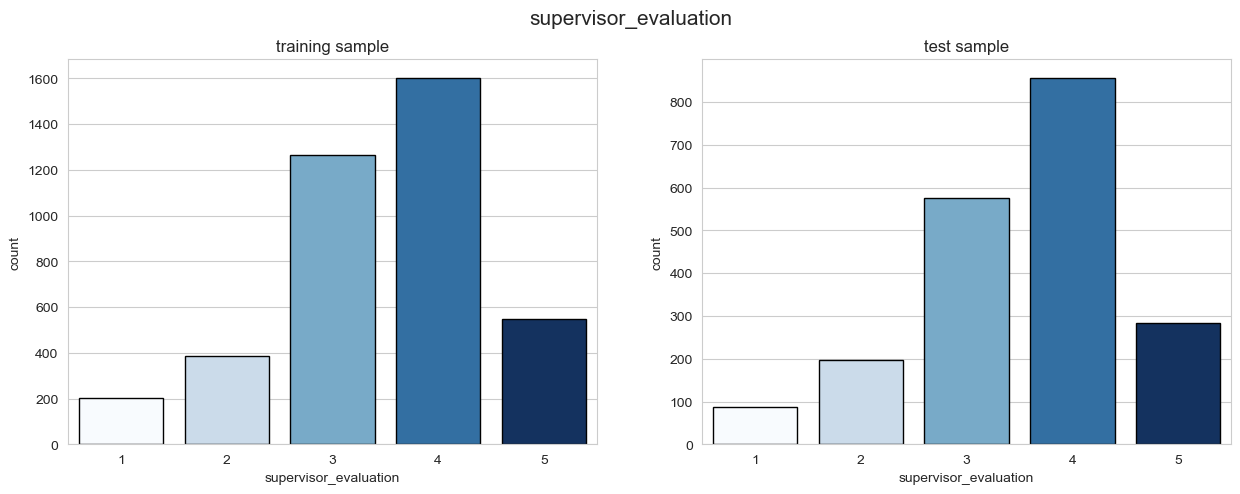

In [29]:
countplot('supervisor_evaluation')

Большинство сотрудников получии от руководства "положительную" оценку: преобладают сотрудники с оценкой 4, чуть меньше сотрудников с оценкой 3. На третьем месте сотрудники с оценкой "отлично". Однако, значительная часть сотрудников получила негативную оценку. 

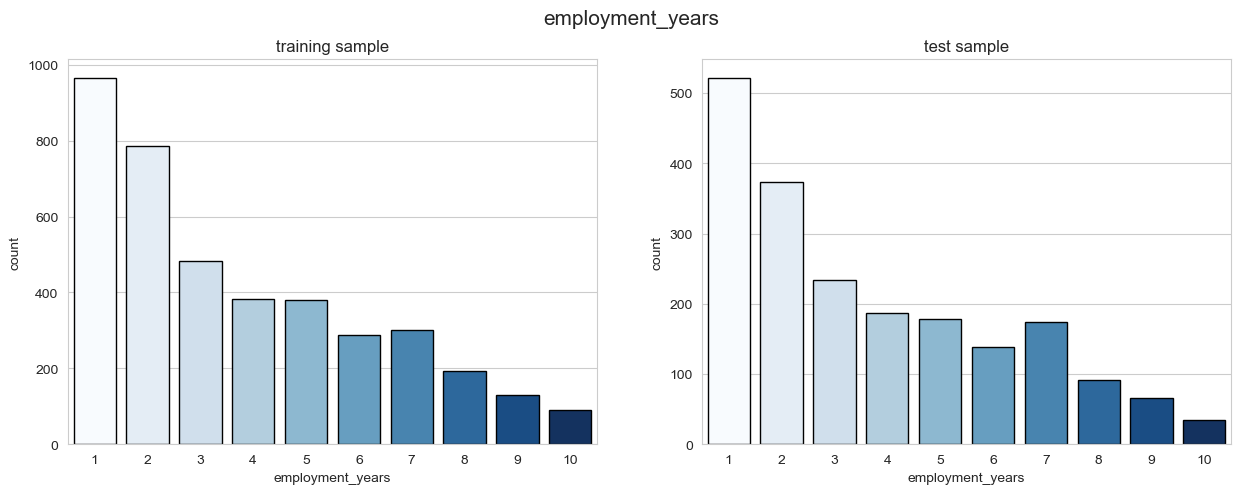

In [30]:
countplot('employment_years')

Распределение сотрудников по годам работы в компании похоже на распределение Пуассона: больше всего специалистов с опытом работы в 1 год и далее с годами трудового стажа количество сотрудников постепенно снижается. Максимальное количество лет работы в компании - 10 лет. 

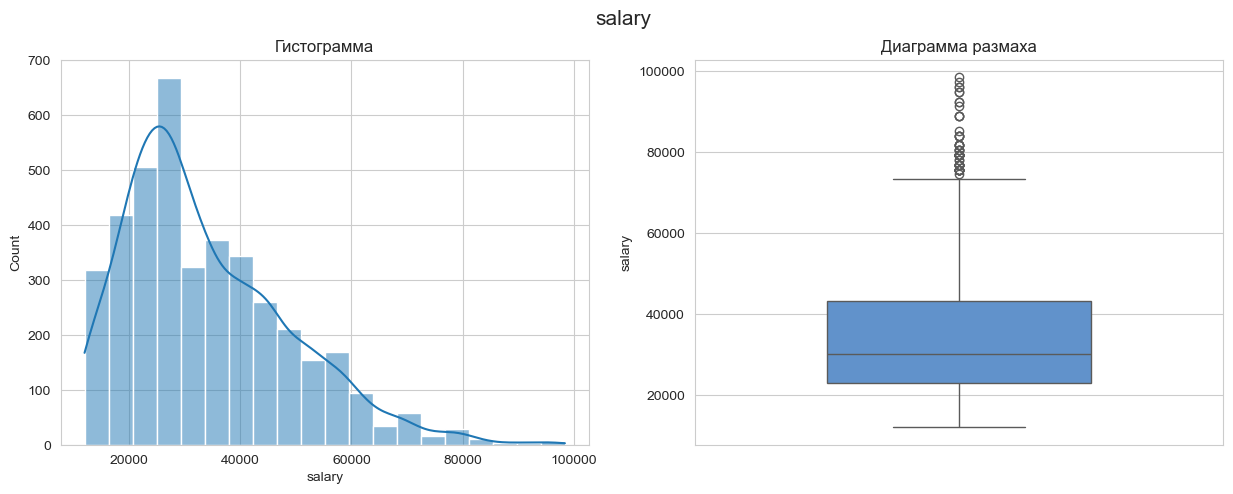

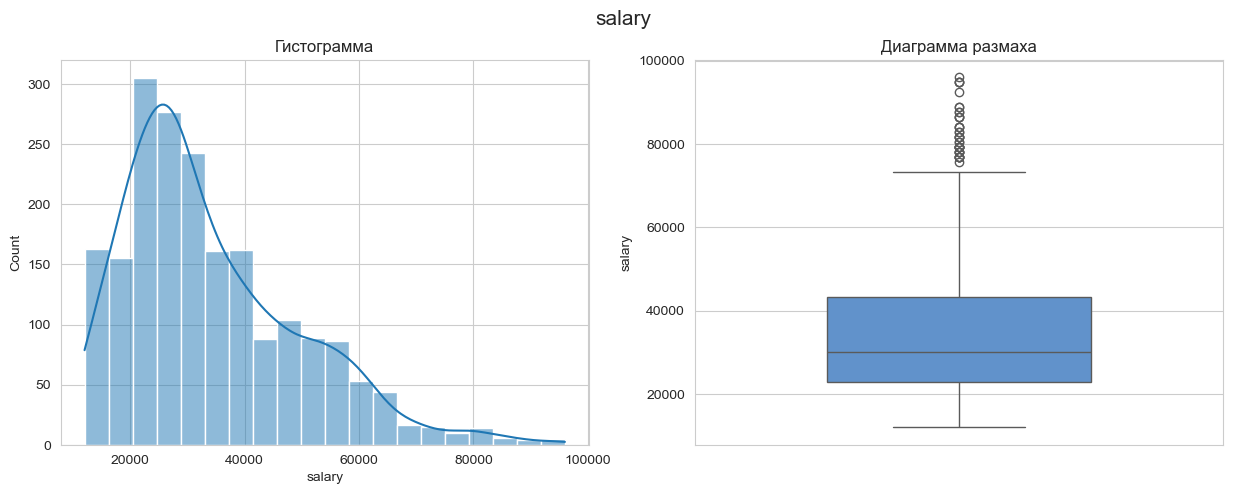

In [31]:
# для тренировочной выборки
hist_and_boxplot('salary', df_train)
# для тестовой выборки
hist_and_boxplot('salary', df_test_features)

Распределение зарплаты сотрудников тоже похоже на распределение Пуассона. У большинства сотрудников зарплата варьируется от 20 до 40 тысяч, средняя зарплата около 30 тысяч. Однако есть сотрудники у которых зарплата достигает почти 100 тысяч.   

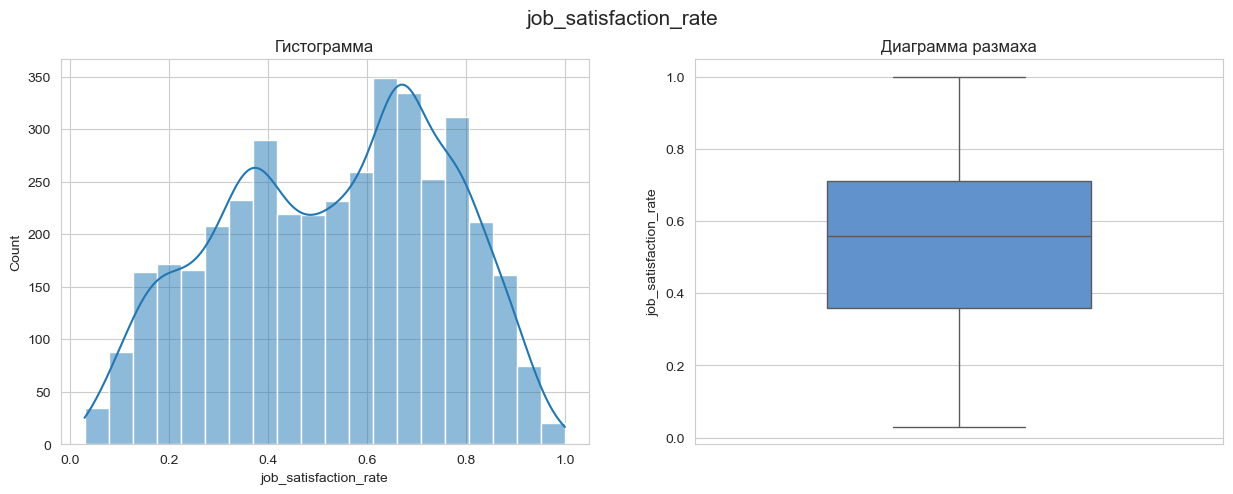

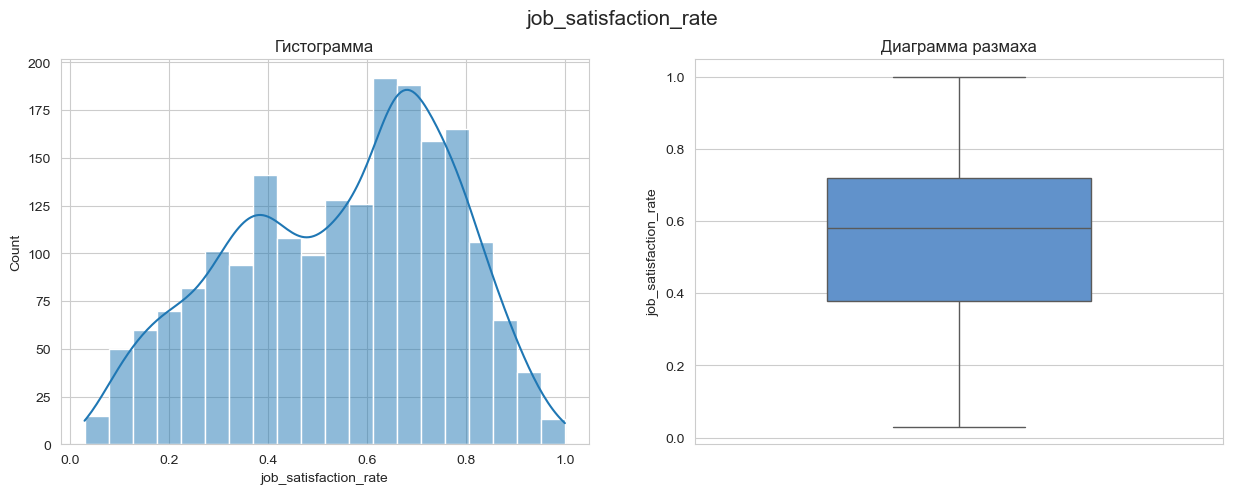

In [32]:
# для тренировочной выборки
hist_and_boxplot('job_satisfaction_rate', df_train)
# для тестовой выборки
hist_and_boxplot('job_satisfaction_rate', df_test_target)

Распределения сотрудников по уровню удовлетворенности работой в компании для тестовой и тренировочной выборки похожи: большинство сотрудников довольны работой примерно от 40 до 70 процентов, но также есть и те, кто не доволен совсем или доволен полностью.       

**Выводы:** 

* Распределения данных тренировочной и тестовой выборки похожи. Это важно для построения эффективной модели прогнозирования
* Сотрудники компании распределны по 5 подразделениям, большинство специалистов работают в отделе продаж
* Примерно половина сотрудников имеют уровень должности junior
* Примерно половина сотрудников имеют средний уровень загруженности
* За прошлый год только 3 процента сотрудников получили повышение  и примерно 14 процентов нарушили ТД
* Работа большинства сотрудников оценивается руководством положительно
* Стаж работы в компании варьируется от 1 до 10 лет: больше всего специалистов с опытом - 1 год, далее с увеличением стажа количество сотрудников снижается
* Зарплата варьируется от 10 до 100 тысяч, медианное значение зарплаты - около 30 тысяч.
* У большинства сотрудников уровень удовлетворенности варьируется от 40% до 70%, при этом присутствует как полностью довольный, так и крайне недовольный персонал

### Корреляционный анализ данных

Построим матрицу корреляции

In [33]:
# непрерывные признаки
interval_cols= df_train[['salary', 'job_satisfaction_rate']]

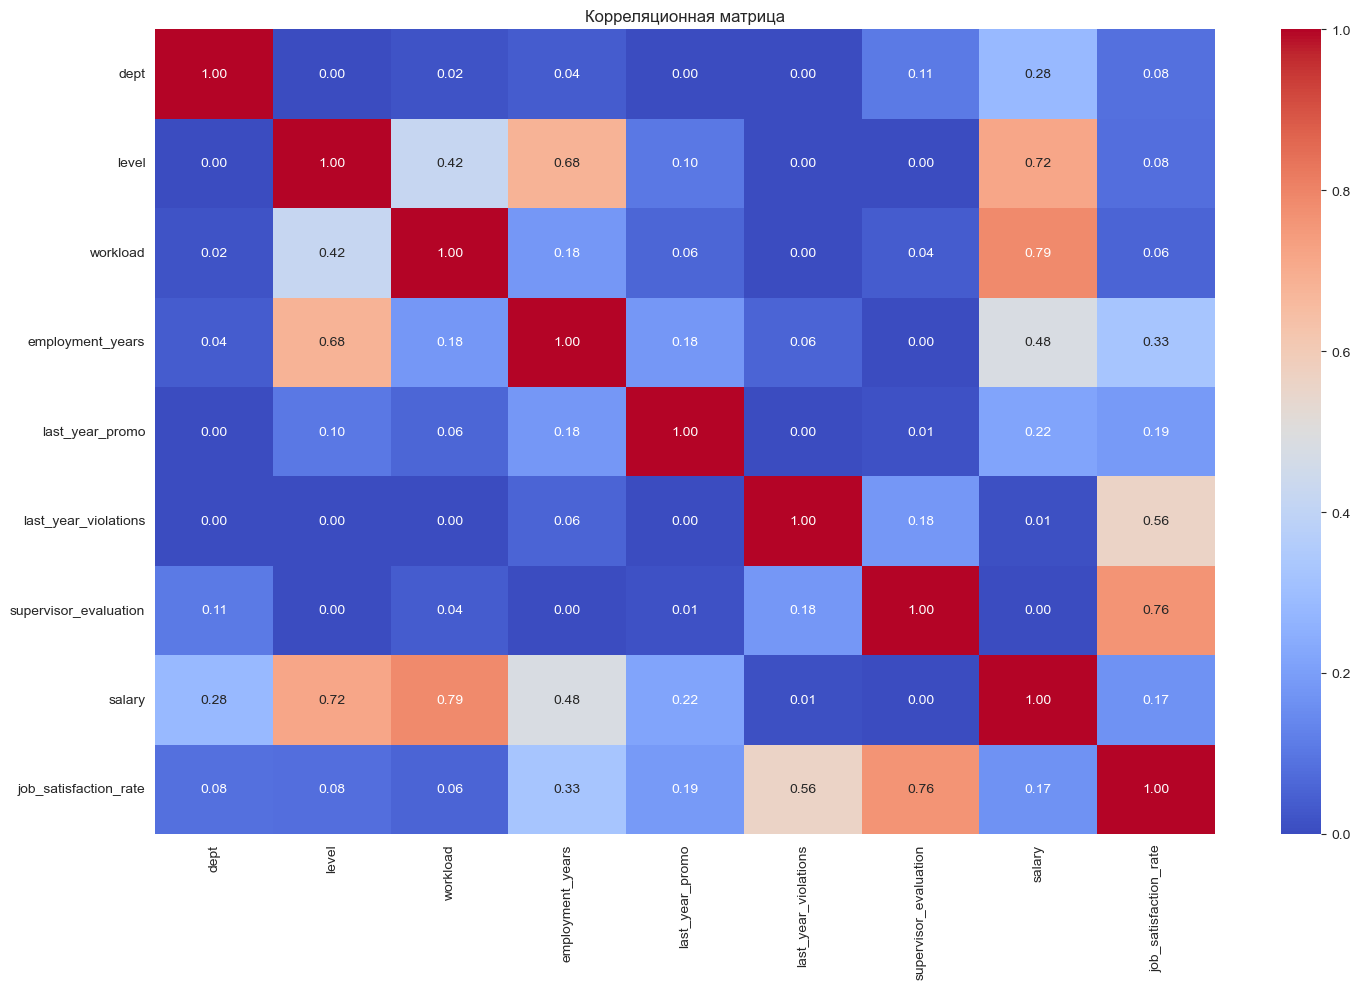

In [34]:
phik_matrix = df_train.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

Целевой признак `job_satisfaction_rate` умеренно коррелирует с `last_year_violations` и сильно коррелирует `supervisor_evalution`. У входных признаков `employment_years` и `salary` есть сильная корреляция с `level`, а также с `workload`.

Аналогично проведем анализ корреляции для тестовой выборки. Объединим тестовые данные по `id` и проверим размер полученной выборки.

In [35]:
df_test = df_test_features.merge(df_test_target, on='id', how='left')
print(f'Размер df_test: {df_test.shape}')
df_test.head()

Размер df_test: (2000, 10)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


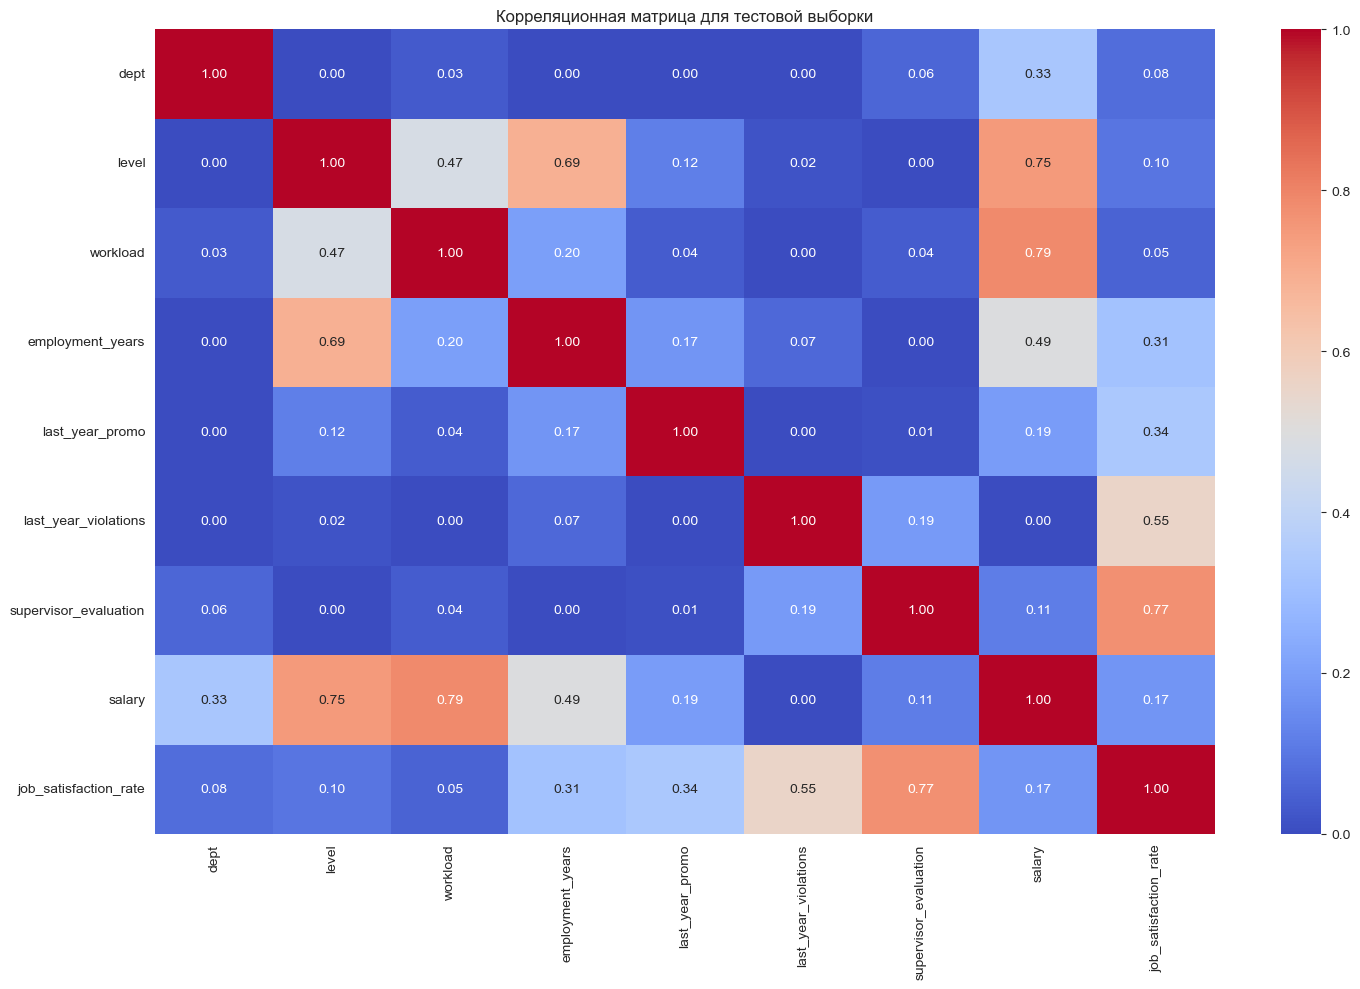

In [36]:
interval_cols_test = df_test[['salary', 'job_satisfaction_rate']]
phik_matrix_test = df_test.drop('id', axis=1).phik_matrix(interval_cols=interval_cols_test)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix_test, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тестовой выборки")
plt.tight_layout()
plt.show()

Видно, что для тренировочной выборки корреляционная матрица почти не отличается от матрицы тренировочной выборки. Связь между признаками аналогичная.

**Выводы:**
* Наблюдается средняя связь между уровнем удовлетворённости сотрудника работой в компании и наличием нарушений трудового договора 
* Наблюдается сильная связь между уровнем удовлетворённости сотрудника работой в компании и оценкой качества работы сотрудника, которую дал руководитель
* Видна сильная корреляция между зарплатой сотрудника и уровнем его должности, его загруженностью, а также между уровнем должности и количеством лет работы в компании. Несмотря на высокую корреляцию между входными признаками, оставим их, т.к. они отражают разные аспекты работы и их взаимосвязь логична с точки зрения бизнес-процессов. 

При подготовке данных необходимо:
* Обработать пропущенные значения
* Преобразовать категориальные признаки в числовой формат, с учетом порядковых признаков
* Маcштабировать числовые признаки


### Подготовка данных

In [37]:
# скопируем данные из второго датафрейма для дальнейшего использования
df_test_features_2 = df_test_features.copy()
df_test_features_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Для дальнейшего удобства работы с данными установим колонку id в качестве индекса датафрейма. 

In [38]:
# устанавливаем столбец 'id' в качестве индекса
df_train = df_train.set_index('id')
df_train.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


Проверим данные на наличие новых дубликатов.

In [39]:
print(f'В тренировочной выборке {df_train.duplicated().sum()} дубликатов') 
print(f'Доля дубликатов в тренировочной выборке: {(df_train.duplicated().sum()/len(df_train)).round(2)}') 

В тренировочной выборке 245 дубликатов
Доля дубликатов в тренировочной выборке: 0.06


В данных появились явные дубликаты, но их немного, поэтому удалим дубликаты. 

In [40]:
df_train = df_train.drop_duplicates(keep='first')
print(f'В тренировочной выборке стало {df_train.duplicated().sum()} дубликатов') 
print(f'Длина датафрейма после удаления части данных стала {len(df_train)}')

В тренировочной выборке стало 0 дубликатов
Длина датафрейма после удаления части данных стала 3755


Создадим пайплайн для подготовки данных

In [41]:
# определяем целевой и входные признаки
X_train = df_train.drop(['job_satisfaction_rate'], axis=1)
y_train = df_train['job_satisfaction_rate']

In [42]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level','workload']
num_columns = ['employment_years', 'salary','supervisor_evaluation']

In [43]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]
)

In [44]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                               ['junior', 'middle', 'senior'],
                               ['low', 'medium', 'high']
                
                          ],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [45]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

**Вывод**: Для подготовки данных создали пайплайн: закодировали категориальные данные разными методами, обработали при этом пропуски, а также масштабировали данные.

### Обучение моделей

Выбор модели необходимо сделать на основе новой метрики — `SMAPE` (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). С помощью функции `make_scorer` создадим необходимую метрику. 

Успешность модели будет определяться по следующему критерию: значение `SMAPE` на тестовой выборке должно быть не более 15%. 

In [46]:
# функция для расчета метрики SMAPE
def smape(y_true, y_pred):
    metric = 100 / len(y_true) * np.sum(2 * np.abs(y_true-y_pred) / (np.abs(y_pred) + np.abs(y_true)))
    return metric

smape_scorer = make_scorer(smape, greater_is_better=False)

In [47]:
# задаем фиксированное значение для random_state
RANDOM_STATE = 42
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [48]:
param_grid = [{'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
               'models__max_depth': range(2, 16),
               'models__max_features': range(2,11),
               'models__min_samples_split':range(2,11),
               'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},

             {'models': [LinearRegression( )],
              'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']}]

In [49]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1)

# обучение модели
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeR...ndom_state=42)], 'models__max_depth': range(2, 16), 'models__max_features': range(2, 11), 'models__min_samples_split': range(2, 11), ...}, {'models': [LinearRegression()], 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(s...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refit

In [50]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика SMAPE на кросс-валидации:', round(-randomized_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

Лучшей моделью оказалась DecisionTreeRegressor с max_depth=14, max_features=8 и min_samples_split=6. Проверим метрику на тестовой выборке

In [51]:
X_test = df_test_features.set_index('id').sort_index()
y_test = df_test_target.set_index('id').sort_index()

In [52]:
y_predict = randomized_search.predict(X_test)

In [53]:
print(f'Метрика SMAPE на тестовой выборке:',smape(np.array(y_test['job_satisfaction_rate']), y_predict).round(2))

Метрика SMAPE на тестовой выборке: 14.09


Метрика `SMAPE` на тестовой выборке получилась меньше 15 процентов. 

Проверим модель на адекватность и посчитаем метрику для константной DummyClassifier.

In [54]:
# создание и обучение модели DummyRegressor
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

# предсказание на тестовых данных
dummy_model_predict = dummy_model.predict(X_test)

# посчитаем и выведем метрику SMAPE
dummy_roc = smape(np.array(y_test['job_satisfaction_rate']), dummy_model_predict)
print('SMAPE =', round(dummy_roc, 2))

SMAPE = 38.26


Получилось, что выбранная лучшая модель лучше константной. Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

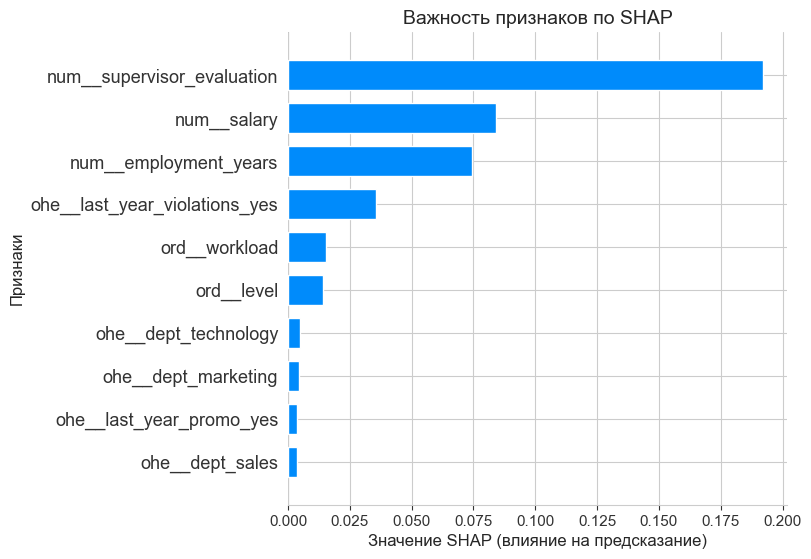

In [55]:
best_pipeline = randomized_search.best_estimator_

# Извлечение модели из пайплайна
model = best_pipeline.named_steps['models']

X_train_shap = pd.DataFrame(
    pipe_final.named_steps['preprocessor'].fit_transform(X_train), 
    columns= pipe_final.named_steps['preprocessor'].get_feature_names_out()
)
X_test_shap = pd.DataFrame(
    pipe_final.named_steps['preprocessor'].transform(X_test), 
    columns= pipe_final.named_steps['preprocessor'].get_feature_names_out()
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)
shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False, max_display=10)
plt.xlabel('Значение SHAP (влияние на предсказание)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков по SHAP', fontsize=14)
plt.show()

Анализ важности признаков выявил три ключевых фактора, оказывающих наибольшее влияние на уровень удовлетворенности сотрудников компании:
* оценка работы сотрудника, которую даёт руководитель
* размер зарплаты
* продолжительность работы в компании, измеренная в годах

**Выводы:** На данном этапе было выполнено обучение нескольких моделей посредством конвейера.

* Обучены 2 модели: `LinearRegression` и `DecisionTreeRegressor`;
  
* Для подбора гиперпараметров использовался рандомизированный поиск для более быстрого поиска;

* Для оценки качества моделей выбрана метрика `SMAPE`;

* В результате метрика `SMAPE` на тестовой выборке для модели `DecisionTreeRegressor` была меньше 15 процентов, это хороший показатель качества модели.


### Выводы

Целью первой части исследования было создание прогностической модели, направленной на оценку уровня удовлетворенности сотрудника в компании.

При оценке качества модели использовалась метрика `SMAPE` (Symmetric Mean Absolute Percentage Error), при этом  критерием успеха считалась SMAPE ≤15 на тестовой выборке.

В ходе работы были проанализированы две регрессионные модели:
* `LinearRegression`
* `DecisionTreeRegressor`

Лучшей была выбрана модель `DecisionTreeRegressor` (max_depth=14, max_features=8, min_samples_split=6). Преимущества это модели обусловлены её способностью учитывать нелинейные зависимости в данных и выявлять сложные взаимосвязи между признаками. В то время как `LinearRegression` основывается на предположении о линейной зависимости между входными признаками и целевой переменной.

Анализ важности признаков выявил, что на уровень удовлетворенности сотрудников больше всего влияют:
* оценка руководителя (`supervisor_evaluation`);

* размер заработной платы (`salary`);
  
* стаж работы в компании (`employment_years`).


## Задача 2: предсказание увольнения сотрудника из компании

### Загрузка данных

Загрузим новые данные. Тестовая выборка входных признаков осталась прежней 

In [56]:
try:
    df_quit = pd.read_csv('/datasets/train_quit.csv')
    df_test_quit = pd.read_csv('/datasets/test_target_quit.csv')
except:
    df_quit = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv')
    df_test_quit = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv')

In [57]:
# выводим общую информацию и первые строки нового датафрейма
print(df_quit.info())
df_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB
None


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


В новой тренировочной выборке добавилась информация о увольнении сотрудника из компании вместо уровня удовлетворенности работой. Всего 4000 строк и 10 столбцов, пропущенных значений нет, типы данных подходящие.

In [58]:
print(df_test_quit.info())
df_test_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB
None


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Целевым признаком теперь является информация от том уволился ли сотрудник из компании. В тестовой выборке 2000 строк, пропусков нет, типы данных подходящие.

**Вывод:** Загрузили и изучили два новых датафрейма. В `df_quit` содержится информация о 4000 сотрудниках компании, такая же как и в первом датафрейме для первой задаче, но теперь целевым признаком является **quit** - увольнение сотрудника. В `df_test_quit` содержится целевой признак тестовой выборки для 2000 сотрудников.

Входные признаки тестовой выборки хранятся в `df_test_features_2`.

Пропущенных значений в новых датафреймах нет, типы данных и названия столбцов соответствуют требованиям.

###  Предобработка данных

Изучим новые данные на наличие пропусков (еще раз), явных и неявных дубликатов.

In [59]:
# суммарное количество пропусков
print(f'В датафрейме df_quit {df_quit.isna().sum().sum()} пропусков')
print(f'В датафрейме df_test_quit {df_test_quit.isna().sum().sum()} пропусков')

В датафрейме df_quit 0 пропусков
В датафрейме df_test_quit 0 пропусков


In [60]:
# выведем суммарное количество явных дубликатов 
print(f'В тренировочной выборке {df_quit.duplicated().sum()} дубликатов') 
print(f'В тестовой выборке с целевым признаком {df_test_quit.duplicated().sum()} дубликатов')

В тренировочной выборке 0 дубликатов
В тестовой выборке с целевым признаком 0 дубликатов


In [61]:
# выведем суммарное количество дубликатов в столбце id 
print(f'В столбце "id" первого датафрейма {df_quit.duplicated(subset="id").sum()} дубликатов') 
print(f'В столюце "id" третьего датафрейма {df_test_quit.duplicated(subset="id").sum()} дубликатов')

В столбце "id" первого датафрейма 0 дубликатов
В столюце "id" третьего датафрейма 0 дубликатов


In [62]:
# уникальные значения в категориальных столбцах
cat_cols_quit = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit']
for col in cat_cols_quit:
    print(f'В столбце "{col}" следующие уникальные значения: {df_quit[col].unique()}')

В столбце "dept" следующие уникальные значения: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
В столбце "level" следующие уникальные значения: ['middle' 'junior' 'sinior']
В столбце "workload" следующие уникальные значения: ['high' 'medium' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']
В столбце "quit" следующие уникальные значения: ['no' 'yes']


Неявных дубликатов нет, исправим только опечатку в столбце level.

In [63]:
df_quit['level'] = df_quit['level'].str.replace('sinior', 'senior')

In [64]:
print('После преобразований в датафрейме df_ quit:')
for col in cat_cols_quit:
    print(f'В столбце "{col}" следующие уникальные значения: {df_quit[col].unique()}')

После преобразований в датафрейме df_ quit:
В столбце "dept" следующие уникальные значения: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
В столбце "level" следующие уникальные значения: ['middle' 'junior' 'senior']
В столбце "workload" следующие уникальные значения: ['high' 'medium' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']
В столбце "quit" следующие уникальные значения: ['no' 'yes']


**Выводы:** В результате предобработки данных

* Убедились в отсутствии пропущенных значения в новых датафреймах; 
* Проверили отсутсвие явных и неявных дубликатов;
* Исправили обнаруженные опечатки. 

В `df_test_features_2` были пропущенные значения, их обработаем позже в пайплайне.

Данные подготовлены к дальнейшему исследовательскому анализу.

### Исследовательский анализ данных

#### ИАД новой тренировочной выборки

In [65]:
# выведем сводную статистическую информацию 
df_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


Построим круговые диаграммы для категориальных признаков

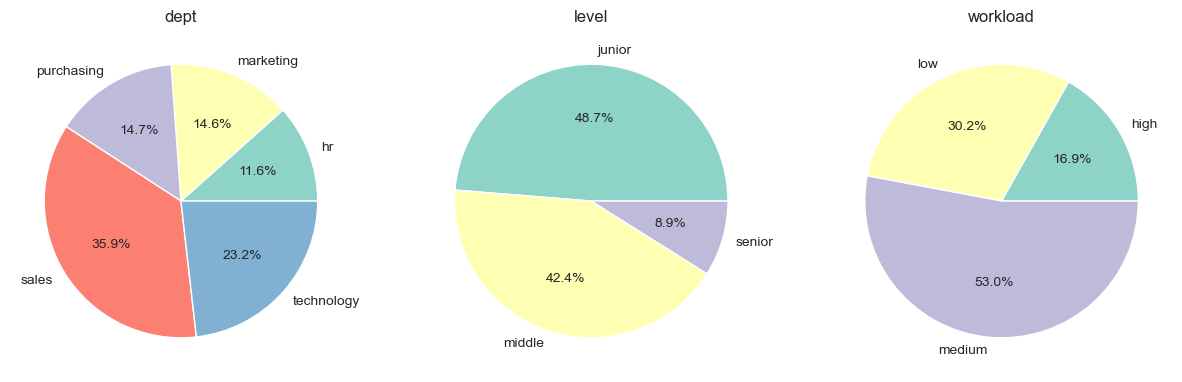

In [66]:
colors = plt.cm.Set3(range(len(df_quit['dept'].unique()))) # используем палитру Set3
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1) 
df_quit.groupby('dept')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('dept')
plt.ylabel('')  
plt.subplot(1, 3, 2) 
df_quit.groupby('level')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('level')
plt.ylabel('')
plt.subplot(1, 3, 3) 
df_quit.groupby('workload')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('workload')
plt.ylabel('')  
plt.show()

В новой выборке также сотрудники распределены по 5 отделам. Около 36 процентов работают в отделе  продаж, примерно 23 в техотделе, примерно одинаковое количество сотрудников работают в отделе закупок и маркетинговом отделе, на последнем месте по количеству сотрудников  - HR отдел.

Примерно половина из всех сотрудников имеют уровень junior, менее 10 процентов имеют статус `senior`.

Средний уровень загруженности у 53 процентов сотрудников, низкий - у 30% и высокий у примерно 17%.

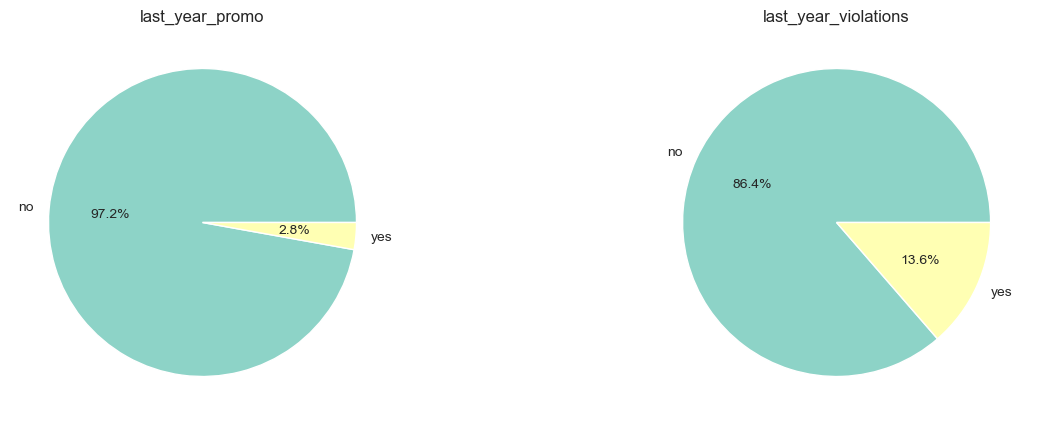

In [67]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1) 
df_quit.groupby('last_year_promo')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('last_year_promo')
plt.ylabel('')  
plt.subplot(1, 2, 2) 
df_quit.groupby('last_year_violations')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('last_year_violations')
plt.ylabel('')
plt.show()

За последний год около трех процентов сотрудников получили повышение и около 14 нарушили ТД.

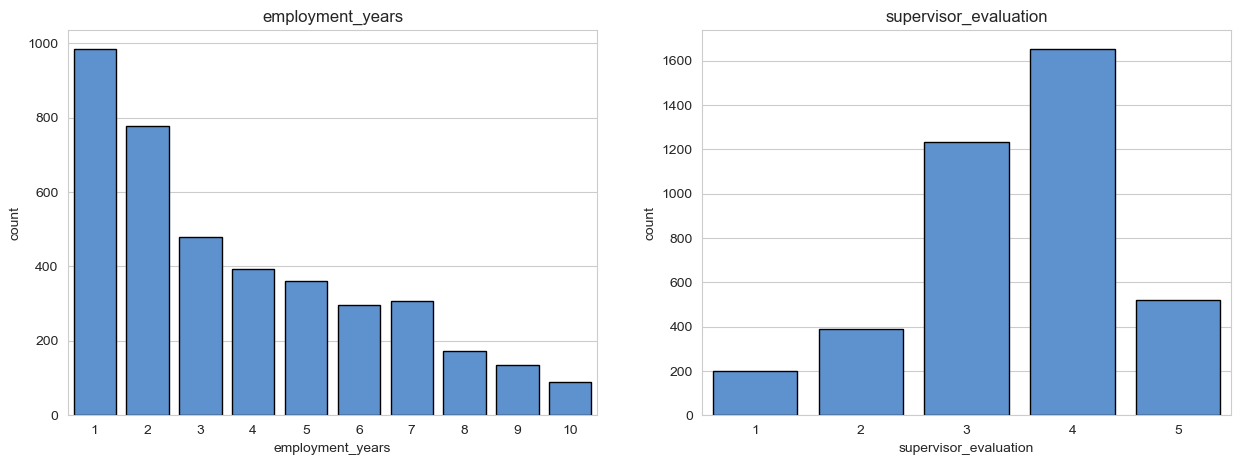

In [68]:
sns.set_style('whitegrid')
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1) 
sns.countplot(x='employment_years',  data=df_quit, color='#4a90e2', edgecolor='black')
plt.title('employment_years')
plt.subplot(1, 2, 2) 
sns.countplot(x='supervisor_evaluation', data=df_quit, color='#4a90e2', edgecolor='black')
plt.title('supervisor_evaluation')
plt.show()

Наибольшее число работников имеют стаж 1 год, далее количество сотрудников уменьшается с ростом стажа. Максимальный стаж работы в компании — 10 лет.

Большинство сотрудников получили положительные оценки руководства: чаще всего встречается оценка *хорошо*, чуть реже - *удовлетворительно*. Сотрудники с оценкой *отлично* составляют третью по численности группу. При этом заметная доля работников получила негативную оценку.

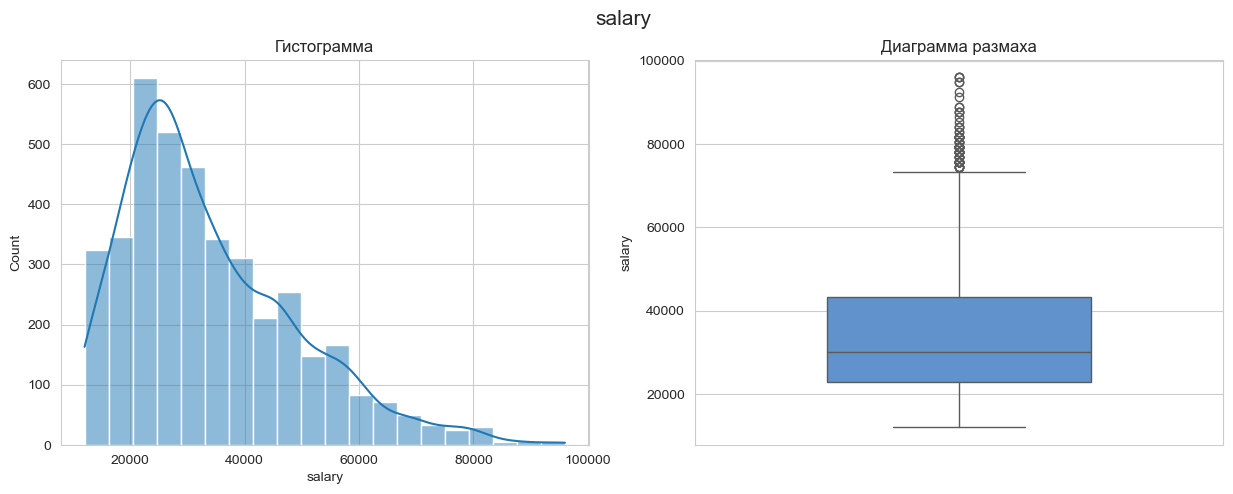

In [69]:
# для тренировочной выборки
hist_and_boxplot('salary', df_quit)

Зарплаты в компании распределены примерно по закону Пуассона. Большинство сотрудников получают от 20 до 40 тыс., в среднем -  около 30 тыс. Но есть и те, кто зарабатывает почти 100 тыс.

#### Анализ портрета уволенного сотрудника

Посмотрим как соотносятся уволившиеся/уволенные сотрудники и сотрудники работающие в компании  

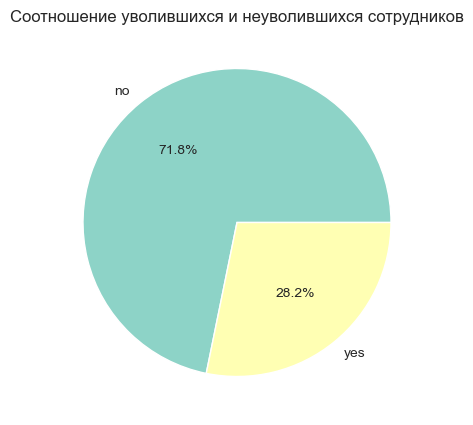

In [70]:
colors = plt.cm.Set3(range(len(df_quit['quit'].unique()))) # используем палитру Set3
plt.figure(figsize=(15, 5))
df_quit.groupby('quit')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('Соотношение уволившихся и неуволившихся сотрудников')
plt.ylabel('')  
plt.show()

Почти 30 процентов сотрудников были уволены с работы (в том числе по собственному желанию). Таким образом, есть несбалансированность классов, это нужно учесть при построении модели.

Для дальнейшего анализа разобъем `df_quit` на две подвыборки: уволенные и не уволенные сотрудники

In [71]:
df_quit_yes = df_quit.query('quit == "yes"')
df_quit_no = df_quit.query('quit == "no"')

In [72]:
# функция для сравнения распределений категориальных признаков для уволенных и действующих сотрудников 
def pie_chart2(x):
    colors = plt.cm.Set3(range(len(df_train[x].unique()))) # используем палитру Set3
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    df_quit_yes.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('Уволенные сотрудники')
    plt.ylabel('')  
    plt.subplot(1, 2, 2) 
    df_quit_no.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('Неуволенные сотрудники')
    plt.ylabel('')  
    plt.suptitle(x, fontsize=15)
    plt.show()

In [118]:
# функция для сравнения распределений дискретных признаков для уволенных и действующих сотрудников 
def countplot2(x):
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    sns.countplot(x=x, data=df_quit_yes, color='#4a90e2', edgecolor='black')
    plt.title('Уволенные сотрудники')
    plt.subplot(1, 2, 2) 
    sns.countplot(x=x, data=df_quit_no, color='#4a90e2', edgecolor='black')
    plt.title('Неуволенные сотрудники')
    plt.suptitle(x, fontsize=15)
    plt.show()

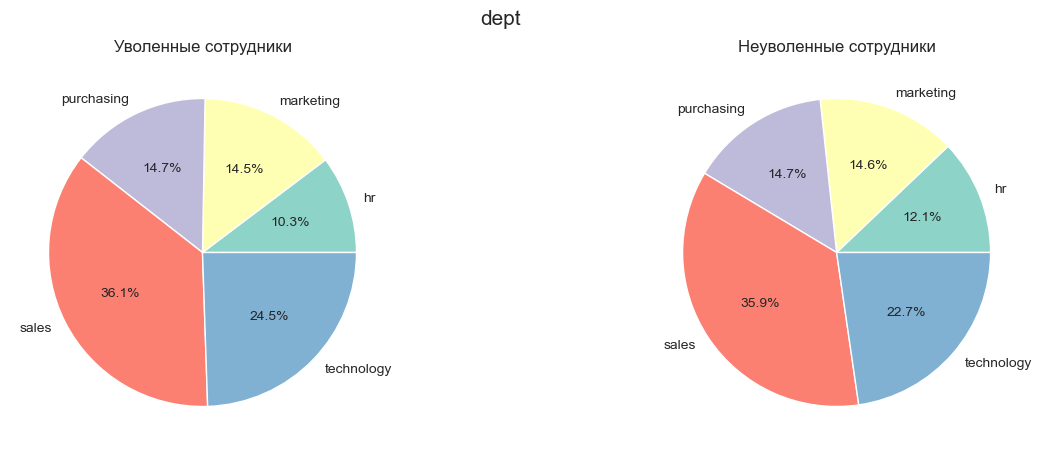

In [74]:
pie_chart2('dept')

Распределение уволенных и действующих сотрудников по отделам примерно одинаково и соответвует распределению общего числа сотрудников, построенного в первой части. Т.е. количество уволенных кадров в каждом отделе пропорционально общему количеству сотрудников в отделе.

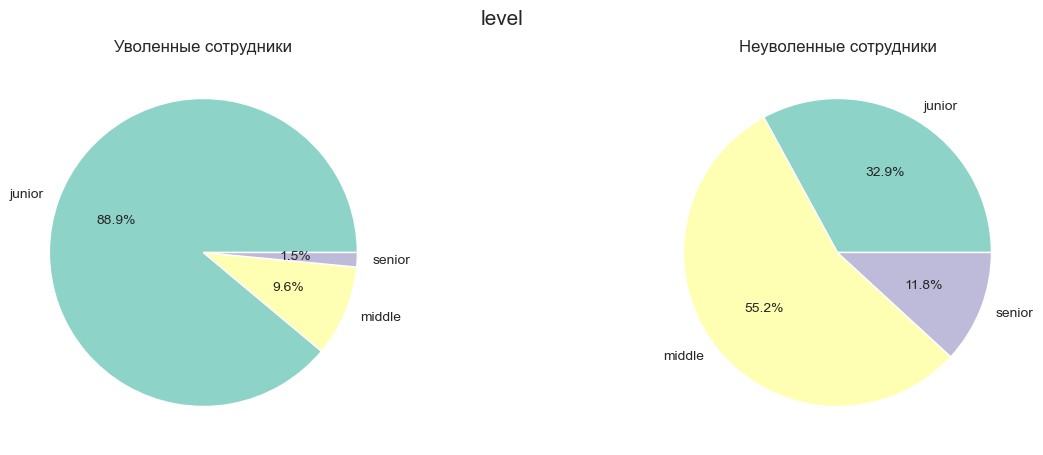

In [75]:
pie_chart2('level')

Видно значительное преобладание junior-специалистов среди уволенных сотрудников, почти 90 процентов. При этом количество уволенных senior-специалистов 1,5 процента.   

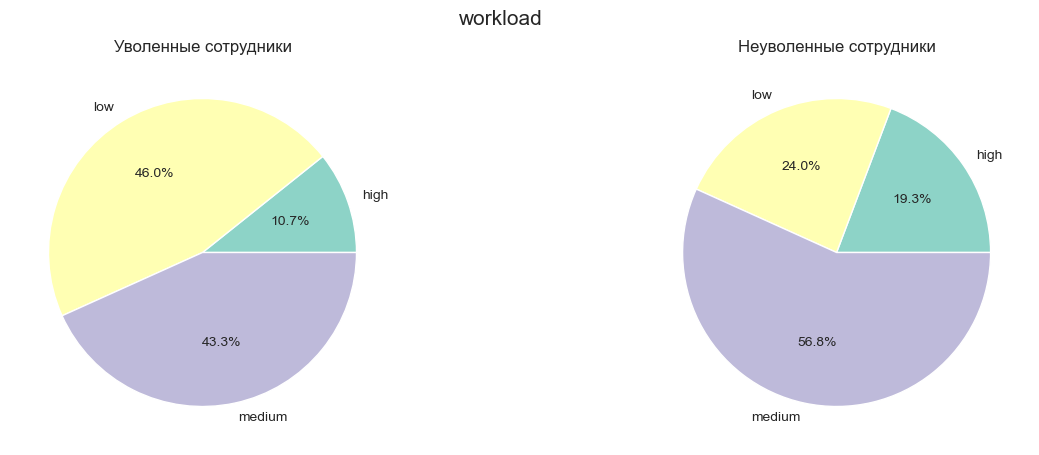

In [76]:
pie_chart2('workload')

Среди уволенных сотрудников примерно одинаковый процент сотрудников с низким и средним уровнем загруженностью. В сумме они составляют около 90 процентов от общего числа уволившихся сотрудников.

Среди действующих сотрудников более половины сотрудников имеют средний уровень загруженности. 

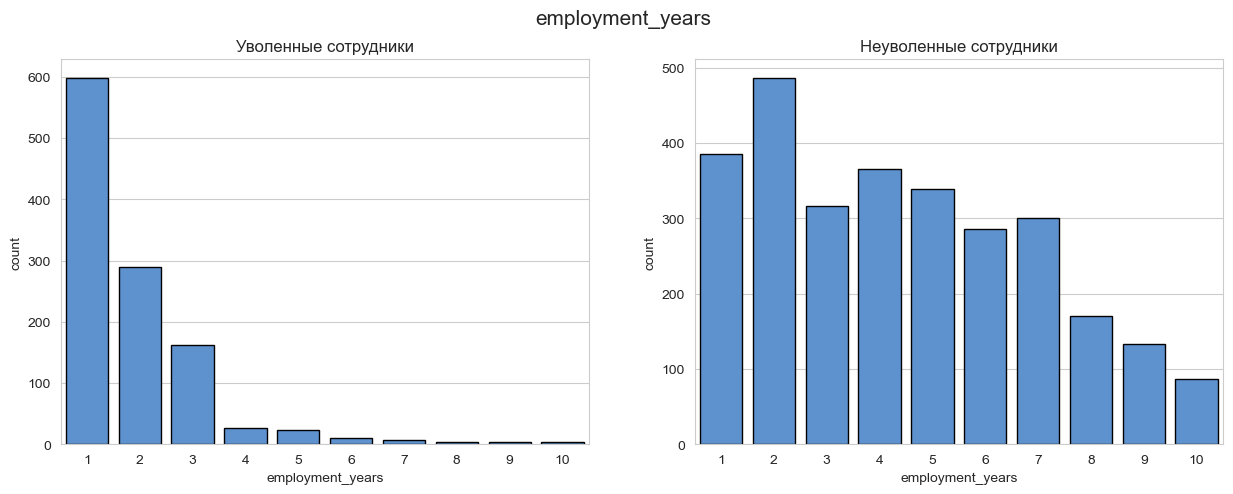

In [119]:
countplot2('employment_years')

Чаще всего увольняются сотрудники со стажем работы в компании 1 год, далее количество уволенных сотрудников постепенно снижается.

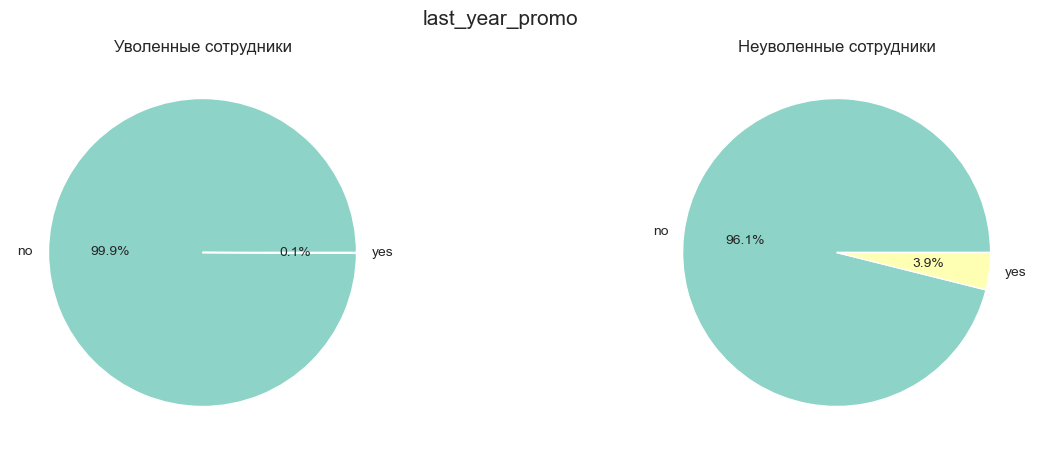

In [78]:
pie_chart2('last_year_promo')

Почти все уволенные сотрудники не получали повышения за прошедший год. 

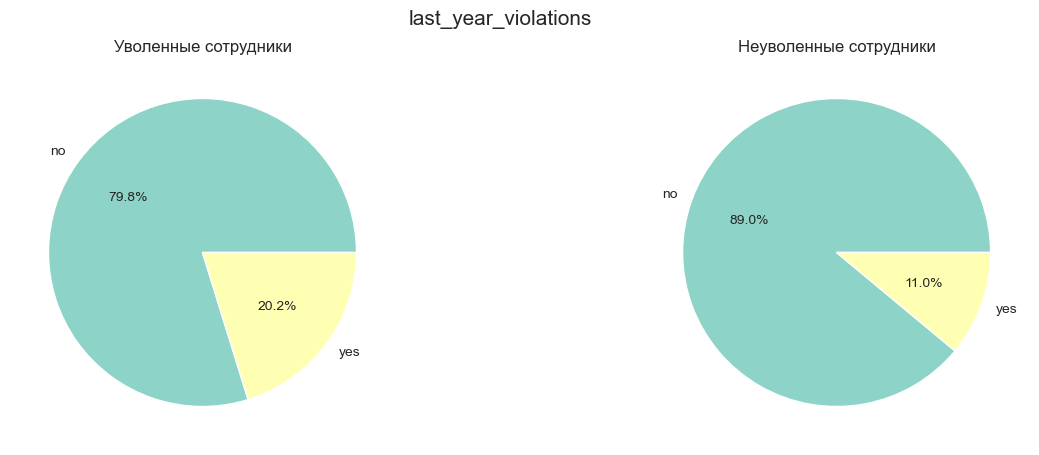

In [79]:
pie_chart2('last_year_violations')

Около 20 процентов уволенных сотрудники нарушали ТД за последнее время, среди работающих сотрудников этот процент в два раза меньше.

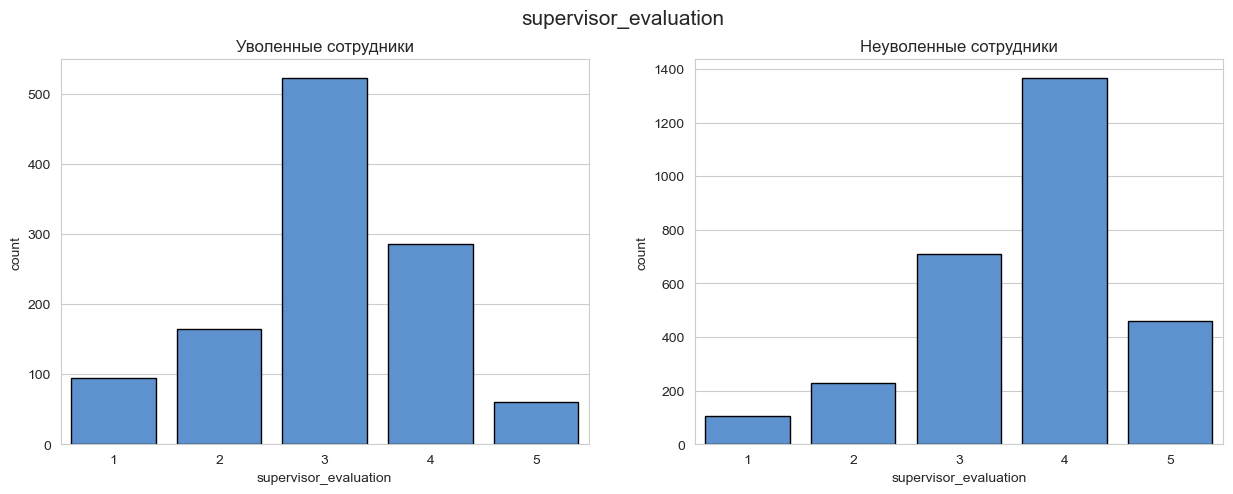

In [120]:
countplot2('supervisor_evaluation')

Чаще работа уволенных сотрудников оценивалась начальством в 3 балла. Они чаще оставшихся сотрудников получали отрицательную оценку (1 и 2 балла) и реже положительную (4 и 5).

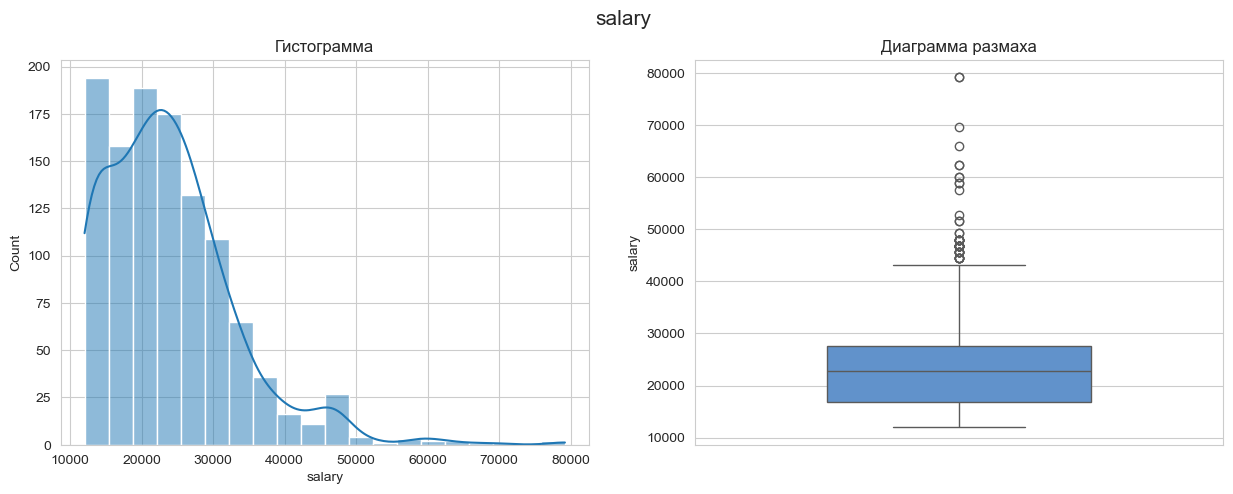

In [81]:
#гистограмма и диаграмма размаха зарплаты уволенных сотрудников
hist_and_boxplot('salary', df_quit_yes)

In [82]:
df_quit_yes['salary'].describe()

count     1128.000000
mean     23885.106383
std       9351.599505
min      12000.000000
25%      16800.000000
50%      22800.000000
75%      27600.000000
max      79200.000000
Name: salary, dtype: float64

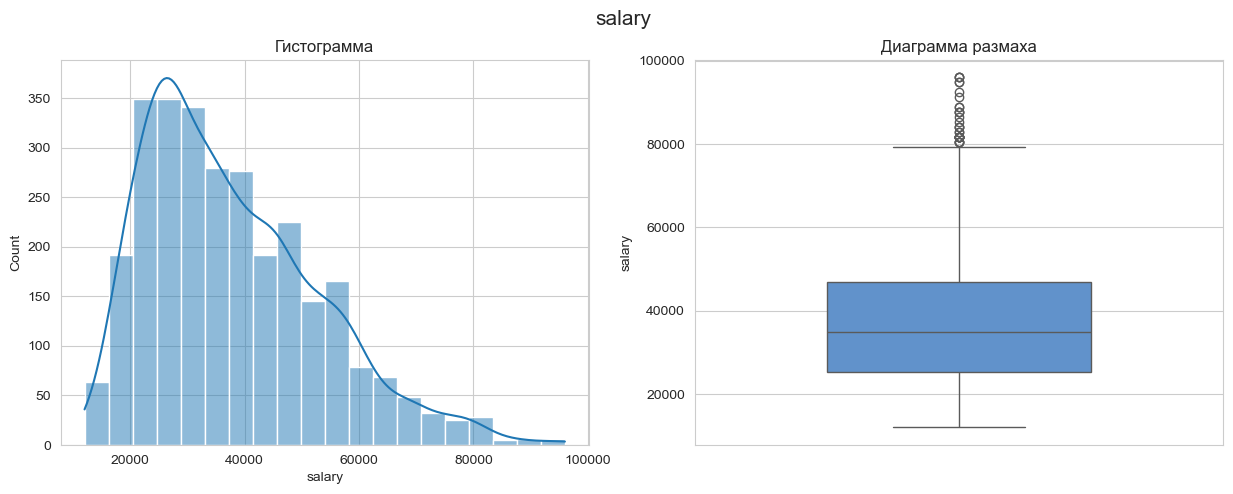

In [83]:
#гистограмма и диаграмма размаха зарплаты действующих сотрудников
hist_and_boxplot('salary', df_quit_no)

In [84]:
df_quit_no['salary'].describe()

count     2872.000000
mean     37702.228412
std      15218.977339
min      12000.000000
25%      25200.000000
50%      34800.000000
75%      46800.000000
max      96000.000000
Name: salary, dtype: float64

Средняя зарплата уволенных сотрудников около 20 тысяч, в то время как средняя зарплата действующих - около 40 тысяч. Большая часть уволенных сотрудников получала от 10 до 30 тысяч.  

Таким образом, **портрет «уволившегося сотрудника»** следующий:
* junior-специалист с небольшим опытом работы (от года до трех лет);

* имеет низкий или средний уровень загруженности;

* имеет относительно небольшую зарплату (около 20 тысяч) и за последний год не получал повышения;
  
* мог нарушить ТД за последний год и получил среднюю или низкую оценку качества работы от начальства.

#### Распределения признака `job_satisfaction_rate`

Визуализируем и сравним распределения признака `job_satisfaction_rate` для ушедших и оставшихся сотрудников. Для этого используем данные с обоими целевыми признаками тестовой выборки.

In [85]:
print(f'Размер df_test_target: {df_test_target.shape}')
df_test_target.head()

Размер df_test_target: (2000, 2)


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [86]:
print(f'Размер df_test_quit: {df_test_quit.shape}')
df_test_quit.head()

Размер df_test_quit: (2000, 2)


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Объеденим целевые выборки по id и проверим размер полученного датафрейма.

In [87]:
job_rate_quit = df_test_quit.merge(df_test_target, on='id', how='left')
print(f'Размер job_rate_quit: {job_rate_quit.shape}')
job_rate_quit.head()

Размер job_rate_quit: (2000, 3)


,id,quit,job_satisfaction_rate
0,999029,yes,0.35
1,372846,no,0.21
2,726767,no,0.73
3,490105,no,0.62
4,416898,yes,0.57


Разделим данные на две подвыборки: уволенные и неуволенные сотрудники.

In [88]:
job_rate_quit_yes = job_rate_quit[job_rate_quit['quit'] == 'yes']
job_rate_quit_no = job_rate_quit[job_rate_quit['quit'] == 'no']

In [89]:
print(f'Количество уволенных сотрудников {len(job_rate_quit_yes)}')
print(f'Количество неуволенных сотрудников {len(job_rate_quit_no)}')

Количество уволенных сотрудников 564
Количество неуволенных сотрудников 1436


Размеры подвыборок сильно отличаются поэтому построим гистограмму плотности распределения для двух подвыборок.  

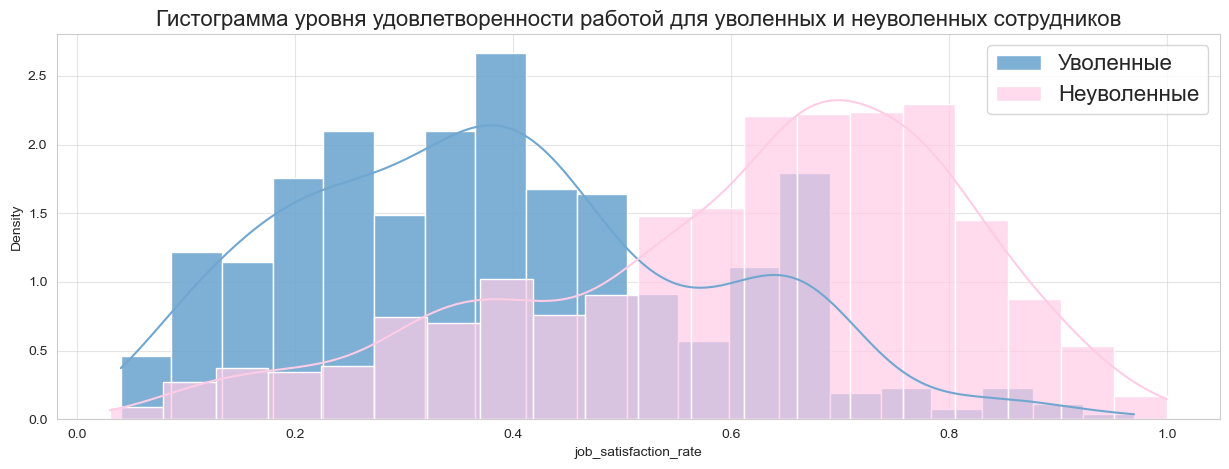

In [90]:
plt.figure(figsize=(15, 5))
sns.histplot(data=job_rate_quit_yes, x='job_satisfaction_rate', label='Уволенные', alpha=0.9, color='#70a7d0', ec='white', \
                 bins=20, kde=True, stat='density', common_norm=False)
sns.histplot(data=job_rate_quit_no,x='job_satisfaction_rate', label='Неуволенные', alpha=0.7, color='#ffcce6', ec='white', \
                 bins=20, kde=True, stat='density', common_norm=False)
plt.title('Гистограмма уровня удовлетворенности работой для уволенных и неуволенных сотрудников', fontsize=16)
plt.legend(loc='upper right', fontsize=16)
plt.grid(alpha=0.5)
plt.show(close=None, block=None)

Видно, что для уволенных сотрудников среднее значение уровня удовлетворенности ниже, чем для действующих сотрудников. Таким образом, уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.

Выдвинем нулевую и альтернативную гипотезы:

**Нулевая гипотеза:** средние значение уровня удовлетворенности для уволенных и неуволенных сотрудников равны.

**Альтернативная гипотеза:** средние значение уровня удовлетворенности для неуволенных сотрудников больше среднего значения уровня удовлетворенности для уволенных.

In [91]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

results = st.ttest_ind(job_rate_quit_no['job_satisfaction_rate'], job_rate_quit_yes['job_satisfaction_rate'], equal_var=False, alternative='greater') #размеры выборок разные

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.385431401577187e-101
Отвергаем нулевую гипотезу


Полученное значение `p-value` меньше заданного уровня значимости (5%), поэтому можно отвергнуть нулевую гипотезу. Есть основания говорить, что средние значение уровня удовлетворенности для неуволенных сотрудников больше.

**Выводы**: По итогам исследовательского анализа данных получилось составить портрет «уволившегося сотрудника». Это junior-специалист с небольшим опытом работы. Скорее всего он имеет низкий или средний уровень загруженности и имеет относительно небольшую зарплату. За последний год такой сотрудник не получал повышения, мог нарушить трудовой договор и получил среднюю или низкую оценку качества работы от начальства.


По гистограмме распределения уровня удовлетворенности уволенных и неуволенных сотрудников получилось увидеть, что уровень удовлетворённости работой и факт увольнения связаны между собой. 

### Корреляционный анализ данных

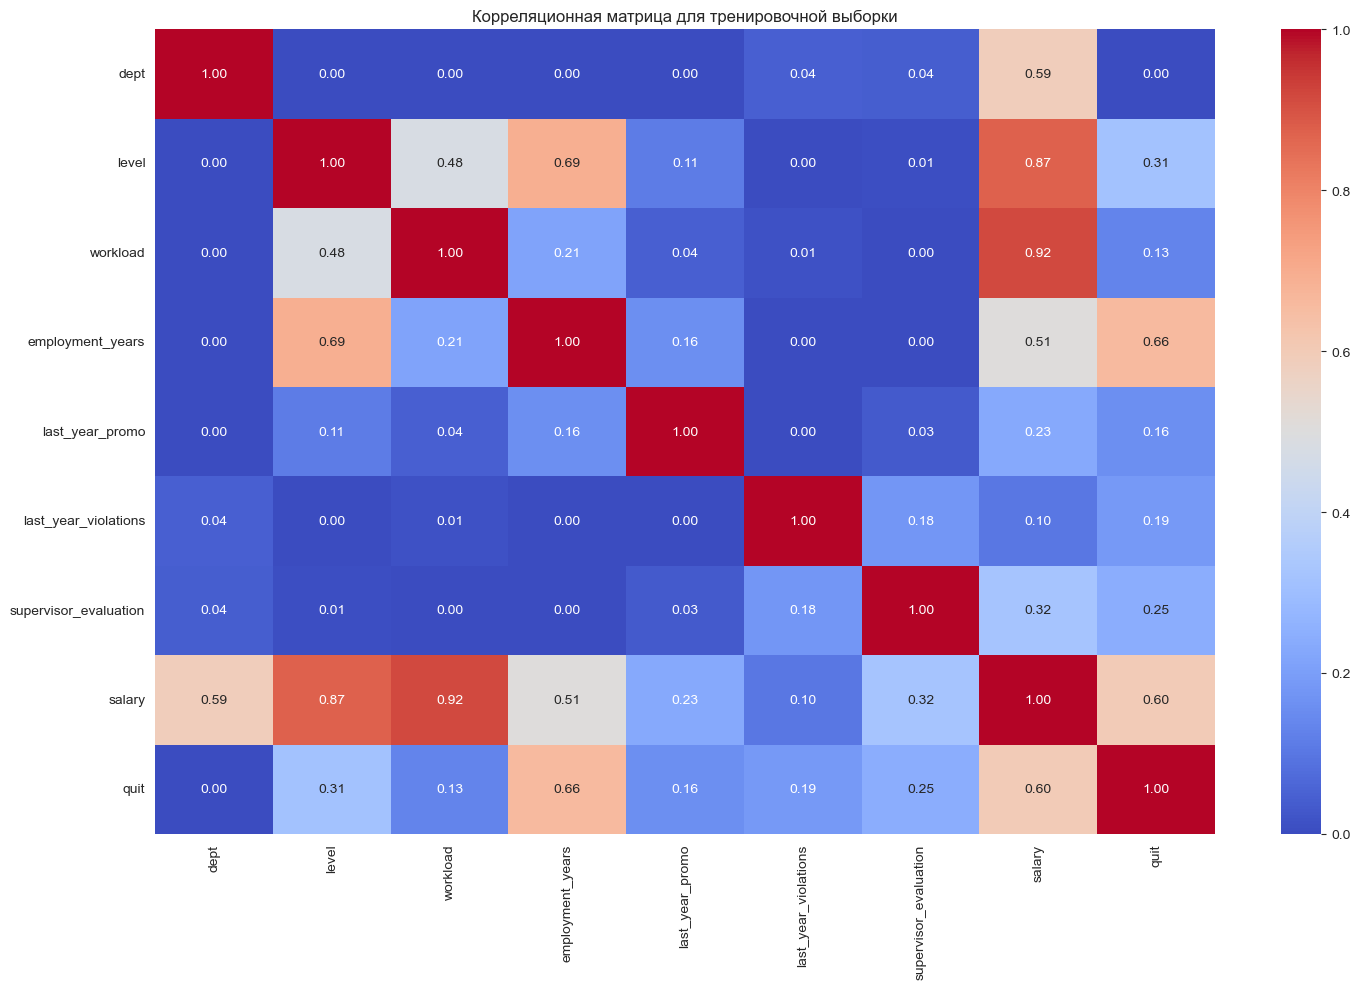

In [92]:
phik_matrix = df_quit.drop('id', axis=1).phik_matrix(interval_cols=df_quit['salary'])
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тренировочной выборки")
plt.tight_layout()
plt.show()

Видна умеренная корреляция между показателем увольнения и стажем работы, а также уровнем зарплаты. Наблюдается сильная взаимосвязь между зарплатой и такими признаками, как отдел компании, уровень должности и нагрузка на сотрудника.

Аналогично проведем анализ корреляции для тестовой выборки. Объединим тестовые данные по id и проверим размер полученной выборки.

In [93]:
df_test_2= df_test_features_2.merge(df_test_quit, on='id', how='left')
print(f'Размер df_test_2: {df_test_2.shape}')
df_test_2.head()

Размер df_test_2: (2000, 10)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,no
1,686555,hr,junior,medium,1,no,no,4,30000,no
2,467458,sales,middle,low,5,no,no,4,19200,no
3,418655,sales,middle,low,6,no,no,4,19200,no
4,789145,hr,middle,medium,5,no,no,5,40800,no


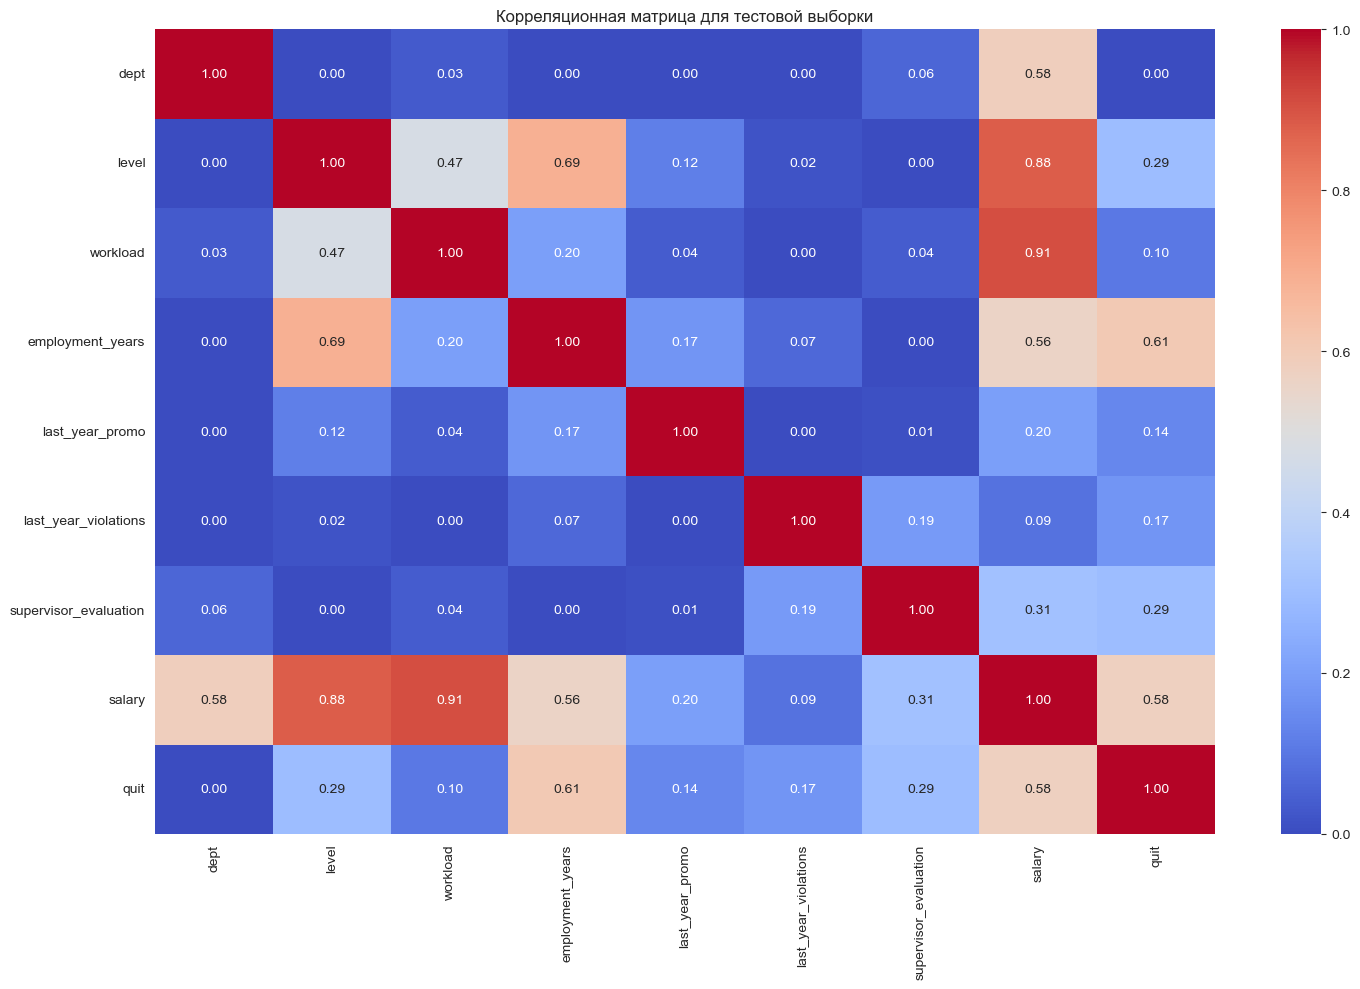

In [94]:
phik_matrix = df_test_2.drop('id', axis=1).phik_matrix(interval_cols=df_quit['salary'])
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тестовой выборки")
plt.tight_layout()
plt.show()

Корреляционная матрица тренировочной выборки практически идентична исходной. Взаимосвязь между признаками сохраняется.

**Выводы:**
* Наблюдается средняя связь между целевым признаком **quit** и признаками **employment_years** и **salary**;
  
* Видна сильная корреляция между **salary** и **dept**, **level**, **workload**. Несмотря на высокую корреляцию между входными признаками, оставим их, т.к. они отражают разные аспекты работы и их взаимосвязь логична с точки зрения бизнес-процессов. 

### Добавление нового входного признака

Добавим `job_satisfaction_rate`, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [95]:
# для тренировочной выборки
print(f'Размер df_quit до добавления признака: {df_quit.shape}')
df_quit['job_satisfaction_rate'] = randomized_search.predict(df_quit.drop('quit', axis=1))
print(f'Размер df_quit после добавления признака: {df_quit.shape}')

Размер df_quit до добавления признака: (4000, 10)
Размер df_quit после добавления признака: (4000, 11)


In [96]:
df_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.635385
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [97]:
# для тестовой выборки
print(f'Размер df_test_features до добавления признака: {df_test_features_2.shape}')
df_test_features_2['job_satisfaction_rate'] = randomized_search.predict(df_test_features_2)
print(f'Размер df_test_features после добавления признака: {df_test_features_2.shape}')

Размер df_test_features до добавления признака: (2000, 9)
Размер df_test_features после добавления признака: (2000, 10)


In [98]:
df_test_features_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.855000
1,686555,hr,junior,medium,1,no,no,4,30000,0.664516
2,467458,sales,middle,low,5,no,no,4,19200,0.654000
3,418655,sales,middle,low,6,no,no,4,19200,0.655000
4,789145,hr,middle,medium,5,no,no,5,40800,0.825306


После того как мы добавили **job_satisfaction_rate**, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи, снова посмотрим как коррелируют новый и исходные признаки в тестовой и тренировочной выборке.

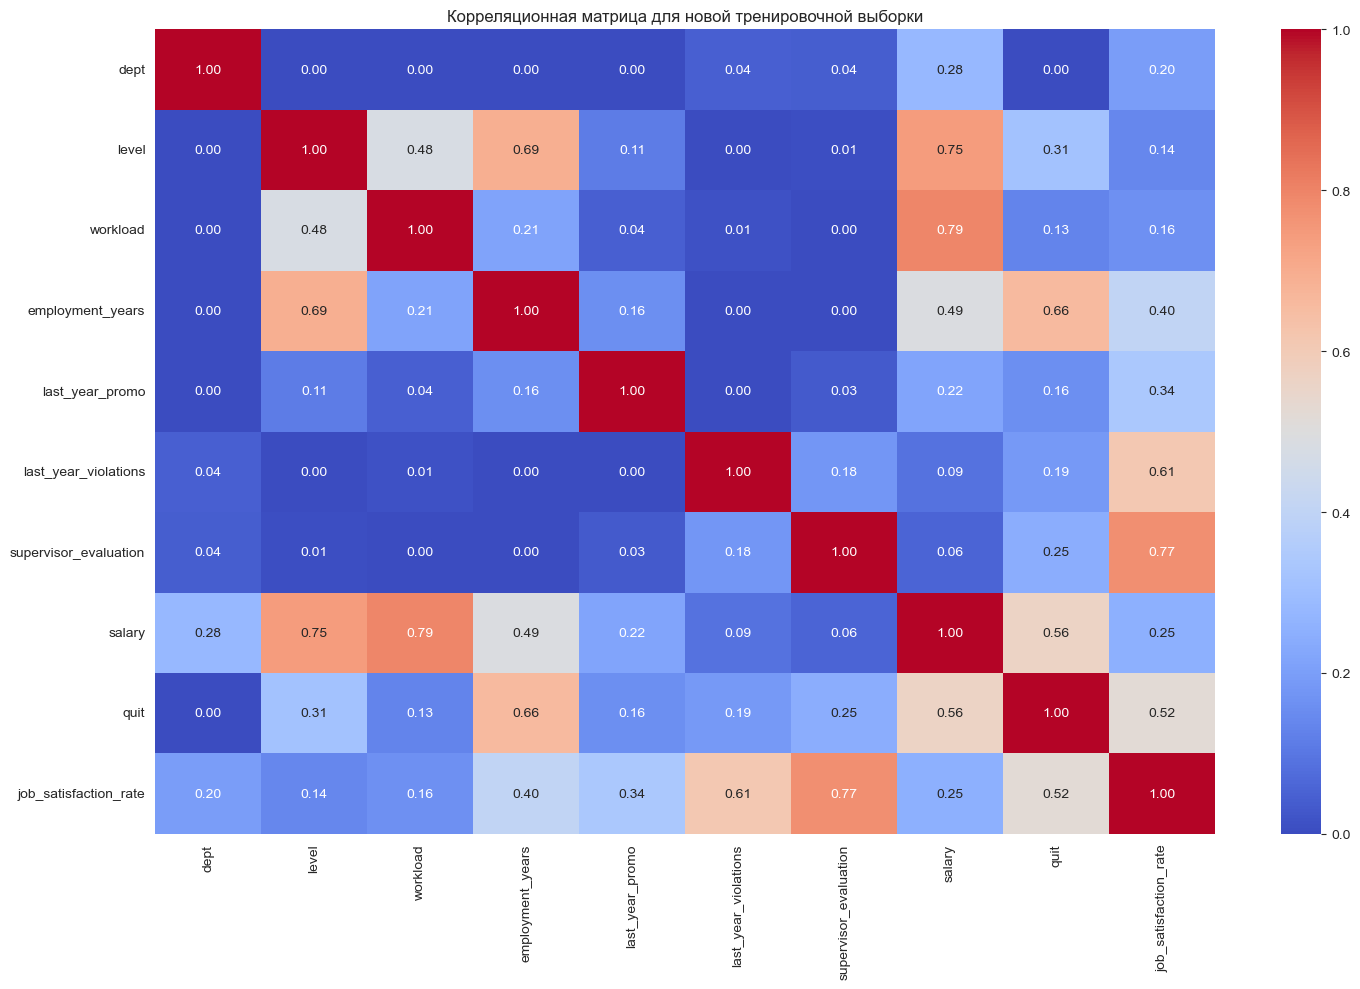

In [99]:
interval_cols_2= df_quit[['salary', 'job_satisfaction_rate']]
phik_matrix = df_quit.drop('id', axis=1).phik_matrix(interval_cols=interval_cols_2)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для новой тренировочной выборки")
plt.tight_layout()
plt.show()

При добавлении нового признака взаимосвязь между исходными признаками практически не поменялась. По прежнему умеренная корреляция между показателем увольнения и стажем работы, а также уровнем зарплаты. Взаимосвязь между зарплатой и такими признаками, как отдел компании, уровень должности и нагрузка на сотрудника стала поменьше. Целевой признак умеренно коррелирует с добавленным новым признаком.

In [100]:
df_test_2= df_test_features_2.merge(df_test_quit, on='id', how='left')
print(f'Размер df_test_2: {df_test_2.shape}')
df_test_2.head()

Размер df_test_2: (2000, 11)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.855000,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.664516,no
2,467458,sales,middle,low,5,no,no,4,19200,0.654000,no
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.825306,no


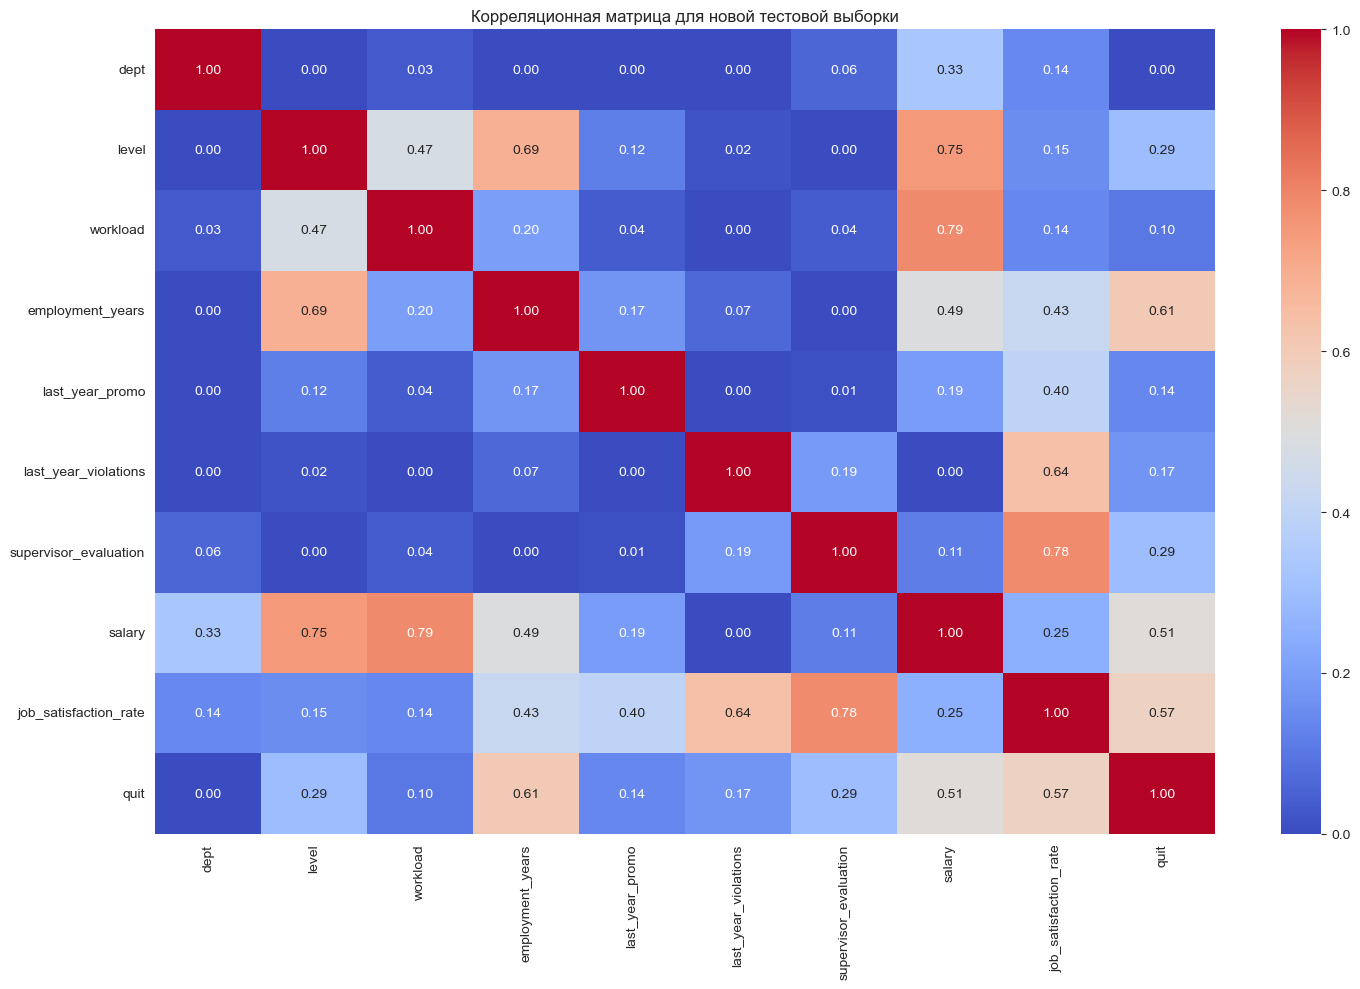

In [101]:
interval_cols_test_2= df_test_2[['salary', 'job_satisfaction_rate']]
phik_matrix = df_test_2.drop('id', axis=1).phik_matrix(interval_cols=interval_cols_test_2)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для новой тестовой выборки")
plt.tight_layout()
plt.show()

По сути, корреляционная матрица тестовой выборки почти такая же, как и для тренировочной, связи между признаками не изменились.

**Вывод:** 
Признаки `job_satisfaction_rate` и `quit` действительно связаны. Поэтому мы добавили `job_satisfaction_rate`, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи. 

Убедились в отсутствии мультиколлинеарности нового признака со старыми.

### Подготовка данных

Для удобства работы с данными установим колонку id в качестве индекса датафрейма и создадим пайплайн для подготовки данных

In [102]:
# устанавливаем столбец 'id' в качестве индекса
df_quit = df_quit.set_index('id')
df_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.635385
814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [103]:
print(f'В тренировочной выборке {df_quit.duplicated().sum()} дубликатов') 
print(f'Доля дубликатов в тренировочной выборке: {(df_quit.duplicated().sum()/len(df_quit)).round(2)}') 
df_quit = df_quit.drop_duplicates(keep='first')
print(f'В тренировочной выборке стало {df_quit.duplicated().sum()} дубликатов') 
print(f'Длина датафрейма после удаления части данных стала {len(df_quit)}')

В тренировочной выборке 1413 дубликатов
Доля дубликатов в тренировочной выборке: 0.35
В тренировочной выборке стало 0 дубликатов
Длина датафрейма после удаления части данных стала 2587


In [104]:
# определяем целевой и входные признаки для тренировочной и тестовой выборки
X_train_2 = df_quit.drop(['quit'], axis=1)
y_train_2 = df_quit['quit']
X_test_2 = df_test_2.drop(['quit'], axis=1)
y_test_2 = df_test_2['quit']

In [105]:
# создаем LabelEncoder для целевой переменной
label_encoder = LabelEncoder()
label_encoder.fit(y_train_2)

# задаем нужный порядок классов
label_encoder.classes_ = np.array(['no', 'yes']) # 'no' -> 0, 'yes' -> 1

# кодируем данные
y_train_encoded = label_encoder.transform(y_train_2)
y_test_encoded = label_encoder.transform(y_test_2)

In [106]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level','workload']
num_columns = ['employment_years', 'salary', 'supervisor_evaluation', 'job_satisfaction_rate']

In [107]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]
)

In [108]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                               ['junior', 'middle', 'senior'],
                               ['low', 'medium', 'high']
                
                          ],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [109]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

**Вывод**: Создали пайплайн для подготовки данных: закодировали категориальные данные разными методами, обработали пропуски, а также масштабировали данные.

### Обучение модели

In [110]:
# задаем фиксированное значение для random_state
RANDOM_STATE = 42
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_2 = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LogisticRegression())
])

In [111]:
param_grid_2 = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 16),
        'models__min_samples_split':range(2,16),
        'models__max_features': range(2, 16),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    }
] 

In [112]:
randomized_search_2 = RandomizedSearchCV(
    pipe_final_2, 
    param_grid_2, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1)

randomized_search_2.fit(X_train_2, y_train_2)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 16), 'models__max_features': range(2, 16), 'models__min_samples_split': range(2, 16), ...}, {'models': [LogisticRegre...ndom_state=42)], 'models__C': range(1, 10), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not

Для оценки качества моделей выбрана метрика ROC-AUC, которая подходит для бинарной классификации с несбалансированной выборкой. В нашем случае уволенных сотрудников значительно меньше, чем  неуволенных.

In [113]:
print('Лучшая модель и её параметры:\n\n', randomized_search_2.best_estimator_)
print ('Метрика на кросс-валидации:', round(randomized_search_2.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

Лучшей моделью оказалась DecisionTreeRegressor с max_depth=4, max_features=14 и min_samples_split=3. Проверим метрику на тестовой выборке

In [114]:
test_score = roc_auc_score(y_test_2, randomized_search_2.predict_proba(X_test_2)[:, 1])
round(test_score, 2)

0.92

Метрика `ROC-AUC` на тестовой выборке получилась больше 0.91, как и требовалось. Проверим модель на адекватность и посчитаем метрику для константной модели DummyClassifier.

In [115]:
# создание и обучение модели DummyClassifier 
dummy_model = DummyClassifier(random_state=RANDOM_STATE, strategy='most_frequent')
dummy_model.fit(X_train_2, y_train_2)

# предсказание на тестовых данных
dummy_model_probas = dummy_model.predict_proba(X_test_2)[:,1]

# посчитаем и выведем метрику ROC-AUC
dummy_roc = roc_auc_score(y_test_2, dummy_model_probas)
print('ROC-AUC =', round(dummy_roc,2))

ROC-AUC = 0.5


Получилось, что выбранная лучшая модель лучше константной. Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

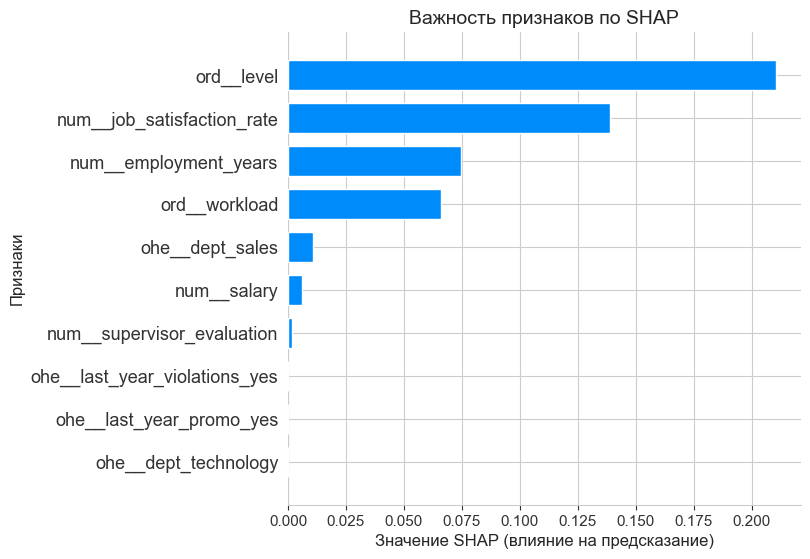

In [116]:
best_pipeline = randomized_search_2.best_estimator_

# Извлечение модели из пайплайна
model = best_pipeline.named_steps['models']

X_train_shap_2 = pd.DataFrame(
    pipe_final_2.named_steps['preprocessor'].fit_transform(X_train_2), 
    columns= pipe_final_2.named_steps['preprocessor'].get_feature_names_out()
)
X_test_shap_2 = pd.DataFrame(
    pipe_final_2.named_steps['preprocessor'].transform(X_test_2), 
    columns= pipe_final_2.named_steps['preprocessor'].get_feature_names_out()
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap_2)
shap.summary_plot(shap_values[:,:,1], X_test_shap_2, plot_type="bar", show=False, max_display=10)
plt.xlabel('Значение SHAP (влияние на предсказание)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков по SHAP', fontsize=14)
plt.show()

Анализ важности признаков выявил три ключевых фактора, оказывающих наибольшее влияние на то уволится ли сотрудник:
* уровень занимаемой должности
* уровень удовлетворённости сотрудника работой в компании
* продолжительность работы в компании, измеренная в годах
* уровень занятости сотрудника

**Вывод:** На данном этапе было выполнено обучение нескольких моделей посредством конвейера.
* Обучены 3 модели: **KNeighborsClassifier**, **DecisionTreeClassifier**, **LogisticRegression**;
  
* Для подбора гиперпараметров использовался рандомизированный поиск для более быстрого поиска;

* Для оценки качества моделей выбрана метрика ROC-AUC, которая подходит для бинарной классификации с несбалансированной выборкой;

* В результате метрика ROC-AUC достигла 0.92 на тестовой выборке для модели **DecisionTreeClassifier**,что является хорошим показателем качества модели. 

### Выводы

С использованием пайплайнов была найдена лучшая модель для предсказания вероятности увольнения сотрудников.

При оценке качества модели использовалась метрика `ROC-AUC`, которая подходит для бинарной классификации с несбалансированной выборкой, при этом критерием успеха считалась значение метрики не меньше 0.91 на тестовой выборке.

В ходе работы были проанализированы три модели:
* KNeighborsClassifier
* DecisionTreeClassifier
* LogisticRegression

Лучшей оказалась модель DecisionTreeClassifier (max_depth=4, max_features=14, min_samples_split=3). Преимущества это модели обусловлены её способностью улавливать сложные нелинейные зависимости между признаками и эффективно обрабатывать данные с большим количеством признаков.

Анализ важности признаков выявил, что на вероятность увольнения больше всего влияют:

* уровень занимаемой должности
* уровень удовлетворённости сотрудника работой в компании
* продолжительность работы в компании, измеренная в годах

## Общий вывод

**Целью работы была разработка эффективных прогностических моделей для оценки уровня удовлетворённости сотрудников работой в компании и предсказания вероятности их увольнения с целью оптимизации HR-процессов и минимизации финансовых потерь компании.**

**Первая задача заключалась в предсказании уровня удовлетворённости сотрудника**

Этапы работы:

**1. Загрузка данных.**

Загружены и проанализированы 3 датафрейма, в которых содержалась информация о сотруднике компании: id сотрудника, отдел, уровень занимаемой должности, уровень загруженности работой, длительность работы в компании, наличие повышения или нарушений трудового договора за последний год, оценка качества работы руководителем, зарплата и уровень удовлетворенности работой в компании. 

**2. Предобработка данных**

Данные были проверены на наличие дубликатов и пропусков, устранены опечатки

**3. Исследовательский анализ данных**

Были построены распределеления для тренировочной и тестовой выборок. Они оказалась похожи:
* Сотрудники компании распределены по 5 подразделениям, большинство специалистов работают в отделе продаж
* Около половины сотрудников имеют уровень должности junior и средний уровень загруженности
* За прошлый год только 3 процента сотрудников получили повышение  и примерно 14 процентов нарушили ТД
* Работа большинства сотрудников оценивается руководством положительно
* Стаж работы в компании варьируется от 1 до 10 лет: больше всего специалистов с опытом - 1 год, далее с увеличением стажа количество сотрудников снижается
* Зарплата варьируется от 10 до 100 тысяч, медианное значение зарплаты - около 30 тысяч.
* У большинства сотрудников уровень удовлетворенности варьируется от 0.4 до 0.7

**4. Корреляционный анализ данных**

Была найдена связь между уровнем удовлетворённости сотрудника работой в компании и оценкой качества работы сотрудника, которую дал руководитель, а также с наличием нарушений трудового договора за последний год

**5. Подготовка данных**

С помощью пайплайна закодировали категориальные данные разными методами, обработали пропуски и масштабировали данные

**6. Обучение моделей**

Были проанализированы две регрессионные модели: `LinearRegression` и  `DecisionTreeRegressor`. Лучшей стала модель `DecisionTreeRegressor` со следующими гиперпараметрами: max_depth=14, max_features=8, min_samples_split=6. Для оценки качества модели использовали метрику `SMAPE`, которая на тестовой выборке была меньше 15 процентов. 

Анализ важности признаков выявил, что на уровень удовлетворенности сотрудников больше всего влияют: оценка руководителя, размер заработной платы и стаж работы в компании.

**Вторая задача заключалась в предсказании увольнения сотрудника из компании**

Этапы работы:

**1. Загрузка данных**

Загружены и проанализированы еще 2 датафрейма, в которых содержалась информация о сотруднике компании: такие же данные как и в первой задаче, но вместо уровня удовлетворенности работой в компании информация об увольнении (уволился/не уволился).  

**2. Предобработка данных**

Данные были проверены на наличие дубликатов и пропусков, устранены опечатки.

**3. Исследовательский анализ данных**

Были построены распределеления для уволенных и неуволенных сотрудников.
* распределения по отделам компании примерно одинаково  
* подавляющая часть уволенных сотрудников специалисты уровня junior
* у уволенных сотрудников низкая или средняя занятость
* у большинства уволенных сотрудников стаж около 1 года
* большинство уволенных работников имело более низкую зарплату
* уволенные сотрудники реже остальных получали повышения и чаще других нарушали трудовой договор
* работа уволенных сотрудников оценивалась руководством ниже

По итогам исследовательского анализа данных получилось составить портрет «уволившегося сотрудника». Это junior-специалист с небольшим опытом работы. Скорее всего он имеет низкий или средний уровень загруженности и имеет относительно небольшую зарплату. За последний год такой сотрудник не получал повышения, мог нарушить трудовой договор и получил среднюю или низкую оценку качества работы от начальства.

По гистограмме распределения уровня удовлетворенности уволенных и неуволенных сотрудников получилось увидеть, что уровень удовлетворённости работой и факт увольнения связаны между собой. 

**4. Корреляционный анализ данных**

Наблюдается средняя связь между целевым признаком (фактом увольнения) и зарплатой и стажем работы в компании

**5. Добавление нового входного признака**

Добавили job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

**6. Подготовка данных**

С помощью пайплайна закодировали категориальные данные разными методами, обработали пропуски и масштабировали данные

**7. Обучение моделей**

С использованием пайплайнов была найдена лучшая модель для предсказания вероятности увольнения сотрудников.

Были обучены три модели: `KNeighborsClassifier`, `DecisionTreeClassifier`, `LogisticRegression`.

Для быстрого подбора гиперпараметров использовался рандомизированный поиск.

Для оценки качества моделей выбрана метрика `ROC-AUC`. Количество неуволенных сотрудников существенно превышает количество уволенных. Использование `ROC-AUC` позволяет корректно оценить качество моделей в условиях такого дисбаланса в данных.

Лучшей моделью стала модель `DecisionTreeClassifier`, которая на тестовой выборке продемонстрировала высокое качество классификации с показателем `ROC-AUC` = 0.92.

Анализ важности признаков выявил, что на вероятность увольнения больше всего влияют: уровень удовлетворенности сотрудника работой в компании, уровень занимаемой должности, стаж работы в компании (employment_years)

**Выводы по результатам исследования:**

* Была построена модель `DecisionTreeRegressor` с `SMAPE` < 15%, позволяющая выявить потенциально неудовлетворенных работой сотрудников. 

* Построена модель `DecisionTreeClassifier` (`ROC-AUC` = 0.92), прогнозирующая увольнение сотрудников.

* Найдены главные факторы удовлетворенности сотрудника: оценка руководителя, зарплата и стаж работы.
  
* Определён портрет увольняющегося сотрудника и доказано, что важный фактор увольнения - уровень удовлетворенности сотрудника работой.

**Предложения для бизнеса**

* Работать с junior-специалистами с небольшим опытом работы, например, разработать программу адаптации в коллективе.

* Разработать систему обучения или поощрять самообучение сотрудников, создав чёткие карьерные перспективы.

* Проанализировать конкурентоспособность зарплат, по возможности создать систему премирования.   

* Создать систему обратной связи, например, организовать систематические обсуждения по результатам работы, уделяя внимание как успехам, так и областям для дальнейшего развития. 